# Alignment

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb)|<i>4.alignment.ipynb</i>|[5.cleanup.ipynb](./5.cleanup.ipynb)|

 This notebook is geared towards aligning the blinks detected by the "Mind Monitor" application, the EEG signal corresponding to that blink, and the blink estimated based on eye-tracking.

 In [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we generated a `src/data2/vr_blinks.csv` file that tracks the blinks detected from the VR eye-tracking data. Furthermore, in [3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb), we generated `src/data2/tp9_blinks.csv` and `src/data2/tp10_blinks.csv`, which tracks blinks detected in the EEG data.

The idea is that we want to estiamte if there's a consistent way to detect the blinks based on the hardware, and then adjust the data to **align** them better. This thus removes any inconsistencies regarding timing, hopefully. The best way to do that is to analyze the three files above.

## A Primer: Blinks and EEG

In the previous notebook ([blink_signals.ipynb](./blink_signals.ipynb)), we uncovered the following graph (it's just a screenshot here):

![](./docs/blink_sample.png)

This is a smoothed ([Savitzky-Golay Filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html), `window_length=100`, `polyorder=3`) EEG signal in the TP9 and TP10 data. This data, which comes from `./data/blink_samples/sample_1.csv`, consists of the following actions:

1. Close eyes, keep closed,
2. from Step 1, open eyes,
3. A normal blink, and
4. A slow blink.

[This report (2022)](https://isip.piconepress.com/conferences/ieee_spmb/2022/papers/l01_03.pdf) directly from the company that made Muse (supposedly) describes their algorithm for detecting blinks using single electrodes. They explain the same thing we've observed - that there's an aggressive valley accompanied by a smaller peak that's associated with a blink gesture. They use an algorithm that's actually kind of effective and makes very little assumptions about the signal behavior prior. They define the blink behavior as such:

Basically, if we want to begin aligning blinks between Muse and other systems, we need to detect the moment when the eyes close or open. In this case, the eyes closing produces such a distinctive response in the EEG that it might be better to find time lags based on the eyes closing. This will be elaborated on further.

## The Current Plan

Each participant's trials has a "calibration" phase. This calibration phase is a moment when a red dot moves back and forth in front of the user in a manner similar to a metronome. This overlap occurs 4 times. We have eye tracking data and eeg data from that instance. From this metric, we can basically identify 1) when the valleys occur around each overlap, and 2) what the eye-tracking data looks like at that same time interval.

### Handling EEG 

We already know that, for the EEG, all we need is to identify the minimum valley moment. We can safely use the [Savitzky-Golay Filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html) as we've used in [blink_signals.ipynb](./blink_signals.ipynb), as all data points are effectively time-locked across the same x-values. I.E. the only real drift we can probably detect if we were to smooth the EEG data is that the peaks somehow switch places with another identical but not-as-strong peak; I don't really find that possibility to be likely, however.

### Handling Eye-Tracking

For the eye tracking data, I want to use a... _unique_ characteristic about the way the **Meta Quest Pro** (MQP) tracks eyes. Basically, **it's all a vision-based model**. When the user blinks, the headset mistakenly reports that the eyes **move downward** when in reality it is likely that either "Bell's Phenomenon" ([Wikipedia](https://en.wikipedia.org/wiki/Bell%27s_phenomenon), [2001 definition](https://pmc.ncbi.nlm.nih.gov/articles/PMC1121451/), [2022 video](https://www.youtube.com/watch?v=wxmBSyWD4mU&t=82s)) or a downward, nasalward movement ([1985 paper](https://doi.org/10.1152/jn.1985.54.1.11)) occurs. Regardless, the MQP will perceive this as a downward movement.

The nature of the MQP's model means that we can effectively detect blinks by isolating what the screen position of the eyes are - specifically, the Y-axis. Valleys in the y-axis screen position of the detected eyes represent when the eyes close during a blink gesture.

## Step 0: Imports

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import importlib
from components import file_handling
from components import eeg_handling

importlib.reload(file_handling)
importlib.reload(eeg_handling)

pd.set_option('display.max_colwidth', None)   # Show full cell contents
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Don't wrap lines
pd.set_option('display.float_format', '{:.0f}'.format)

## Step 1: Filtering Participants

For each participant, for each trial, we have a calibration phase. **Not every calibration phase is viable**. So we need to manually discertain what's the best calibration phases to use for our analysis. We're looking for calibration phases where 1) there's a very clear EEG response that follows the expected pattern (steep valley, steep peak, return to normal), and 2) there's a discernable peak or valley in the eye-tracking data.

### 1a. Filter active participants

In [2]:
_DATA_DIR = './data/'
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P2',
    'P3',
    'P4_Muse2',
    'P5'
]

p_dirs = [{'p':p, 'd':os.path.join(_DATA_DIR, p+'/trials/')} for p in _ACTIVE_PARTICIPANTS]
participants = []
for p in p_dirs:

    # Check that `calibrations.csv` actually exists. If not, then we skip
    if not os.path.exists(p['d']+'calibrations.csv'):
        print(f"'calibrations.csv' does not exist in participant {p['p']}'s folder. Dropping this participant")
        continue
    
    # Read `simulations.csv` for the participant
    sdf = pd.read_csv(os.path.join(p['d'], 'simulations.csv')).drop(columns=['Unnamed: 0'])
    
    # Each `simulations.csv` file indicates the trial order for each participant. Check each folder
    trials = []
    for _, srow in sdf.iterrows():
        # Get the directory to that trial
        sdir = os.path.join(p['d'], f"{srow['trial_id']}/calibration/")
        # We need to check: every calibration directory has a `calibration.csv`, but does it have `eye.csv` and `eeg_raw.csv`?
        if os.path.exists(os.path.join(sdir, 'eye.csv')) and os.path.exists(os.path.join(sdir, 'eeg_raw.csv')):
            # this is a valid trial. Add it
            trials.append({'trial_id':srow['trial_id'], 'd':sdir})
    
    # If `trials` is empty, then this is an invalid participant. Only add to `participants[]` if there's at least one trial that's viable
    if len(trials) > 0:
        participants.append({'p':p['p'], 'd':p['d'], 'trials':trials})


display(Markdown('#### Active participants:'))
participants_str = ''
for p in participants: participants_str += f"- \"{p['p']}\": {len(p['trials'])} trials\n"
display(Markdown(participants_str))

'calibrations.csv' does not exist in participant P2's folder. Dropping this participant


#### Active participants:

- "P1": 6 trials
- "PI2": 6 trials
- "P3": 6 trials
- "P4_Muse2": 6 trials
- "P5": 6 trials


### 1b. Defining blink ranges

The idea is that for every overlap in every calibration trial, we expect a corresponding blink detected by the Muse system. So basically, we need to create windows of time periods that capture the moment when the overlap occurs and when the muse thinks a blink has occurred. We need to reject overlaps where another overlap occurs between the first overlap and the first detected blink after that first overlap. It's not very common and honestly unlikely to happen, but you can never be too sure.

In [3]:
for p in participants:
    for i in range(len(p['trials'])):
        # i = row index
        trial = p['trials'][i]
        # trial is an object with `trial_id` and `d` (directory)
        # calibrations
        cal = pd.read_csv(os.path.join(trial['d'], 'calibration.csv')).drop(columns=['Unnamed: 0'])
        cdf = cal[cal['event'] == 'Overlap']
        # raw eeg and muse-detected blinks.
        muse_blinks = pd.read_csv(os.path.join(trial['d'], 'muse_blinks.csv')).drop(columns=['Unnamed: 0'])
        eeg = pd.read_csv(os.path.join(trial['d'], 'eeg_raw.csv')).drop(columns=['Unnamed: 0'])
        # Ensure that we only consider blinks 5sec after the start of the calibration file
        eeg_first_timestamp = eeg['unix_ms'].iloc[0]
        eeg_last_timestamp = eeg['unix_ms'].iloc[-1]
        muse_blinks = muse_blinks[muse_blinks['unix_ms'].between(eeg_first_timestamp + 5000.0, eeg_last_timestamp - 500)]
        
        # Use asof merge with direction='forward'. This gets the 'next' timestamp in muse_blinks after each overlap
        muse_blinks = muse_blinks.rename(columns={'unix_ms':'blink_unix_ms'})
        ranges = pd.merge_asof(
            cdf, muse_blinks,
            left_on='unix_ms',
            right_on='blink_unix_ms',
            direction='forward'
        )
        ranges = ranges.drop(columns=['frame', 'rel_timestamp', 'event', 'TimeStamp', 'unix_sec', 'rel_sec', 'rel_ms'])
        ranges = ranges[['overlap_counter', 'unix_ms', 'blink_unix_ms']]
        ranges = ranges.rename(columns={'unix_ms':'overlap_unix_ms'})

        # Filter NaN rows or rows where the next overlap timestamp comes before the current blink timestamp
        filtered = ranges.dropna(subset=['blink_unix_ms'])
        next_overlap = filtered['overlap_unix_ms'].shift(-1)
        mask = (next_overlap >= filtered['blink_unix_ms']) | (next_overlap.isna())
        filtered = filtered[mask]

        # We modify the unix milliseconds to account for a 100ms window before the overlap starts and after the blink is the detected
        filtered['start_unix_ms'] = filtered['overlap_unix_ms'] - 100
        filtered['end_unix_ms'] = filtered['blink_unix_ms'] + 100
        filtered['duration'] = filtered['end_unix_ms'] - filtered['start_unix_ms']

        # Let's save the file as `calibration_blinks.csv` inside the trial's calibration directoryt
        filtered.to_csv(os.path.join(trial['d'], 'calibration_blinks.csv'), index=False)


### 1c. Render calibrations

The four data features we want to look at are:

- `eeg_raw.csv`: `TP9` and `TP10`. 
- `eye.csv`: `gaze_target_screen_pos_x` and `gaze_target_screen_pos_y`

Let's also highlight the results from `calibration_blinks.csv` that we saved in Step 1b.

In [4]:
# Define a helper function to plot stuff
def plot_line(_x, _y, _ax, _title=None, _color='black', _marker=None, _alpha=1.0, _label=None):
    _ax.plot(_x, _y, c=_color, marker=_marker, alpha=_alpha, label=_label)
    if _title is not None: _ax.set_title(_title)

### Participant P1

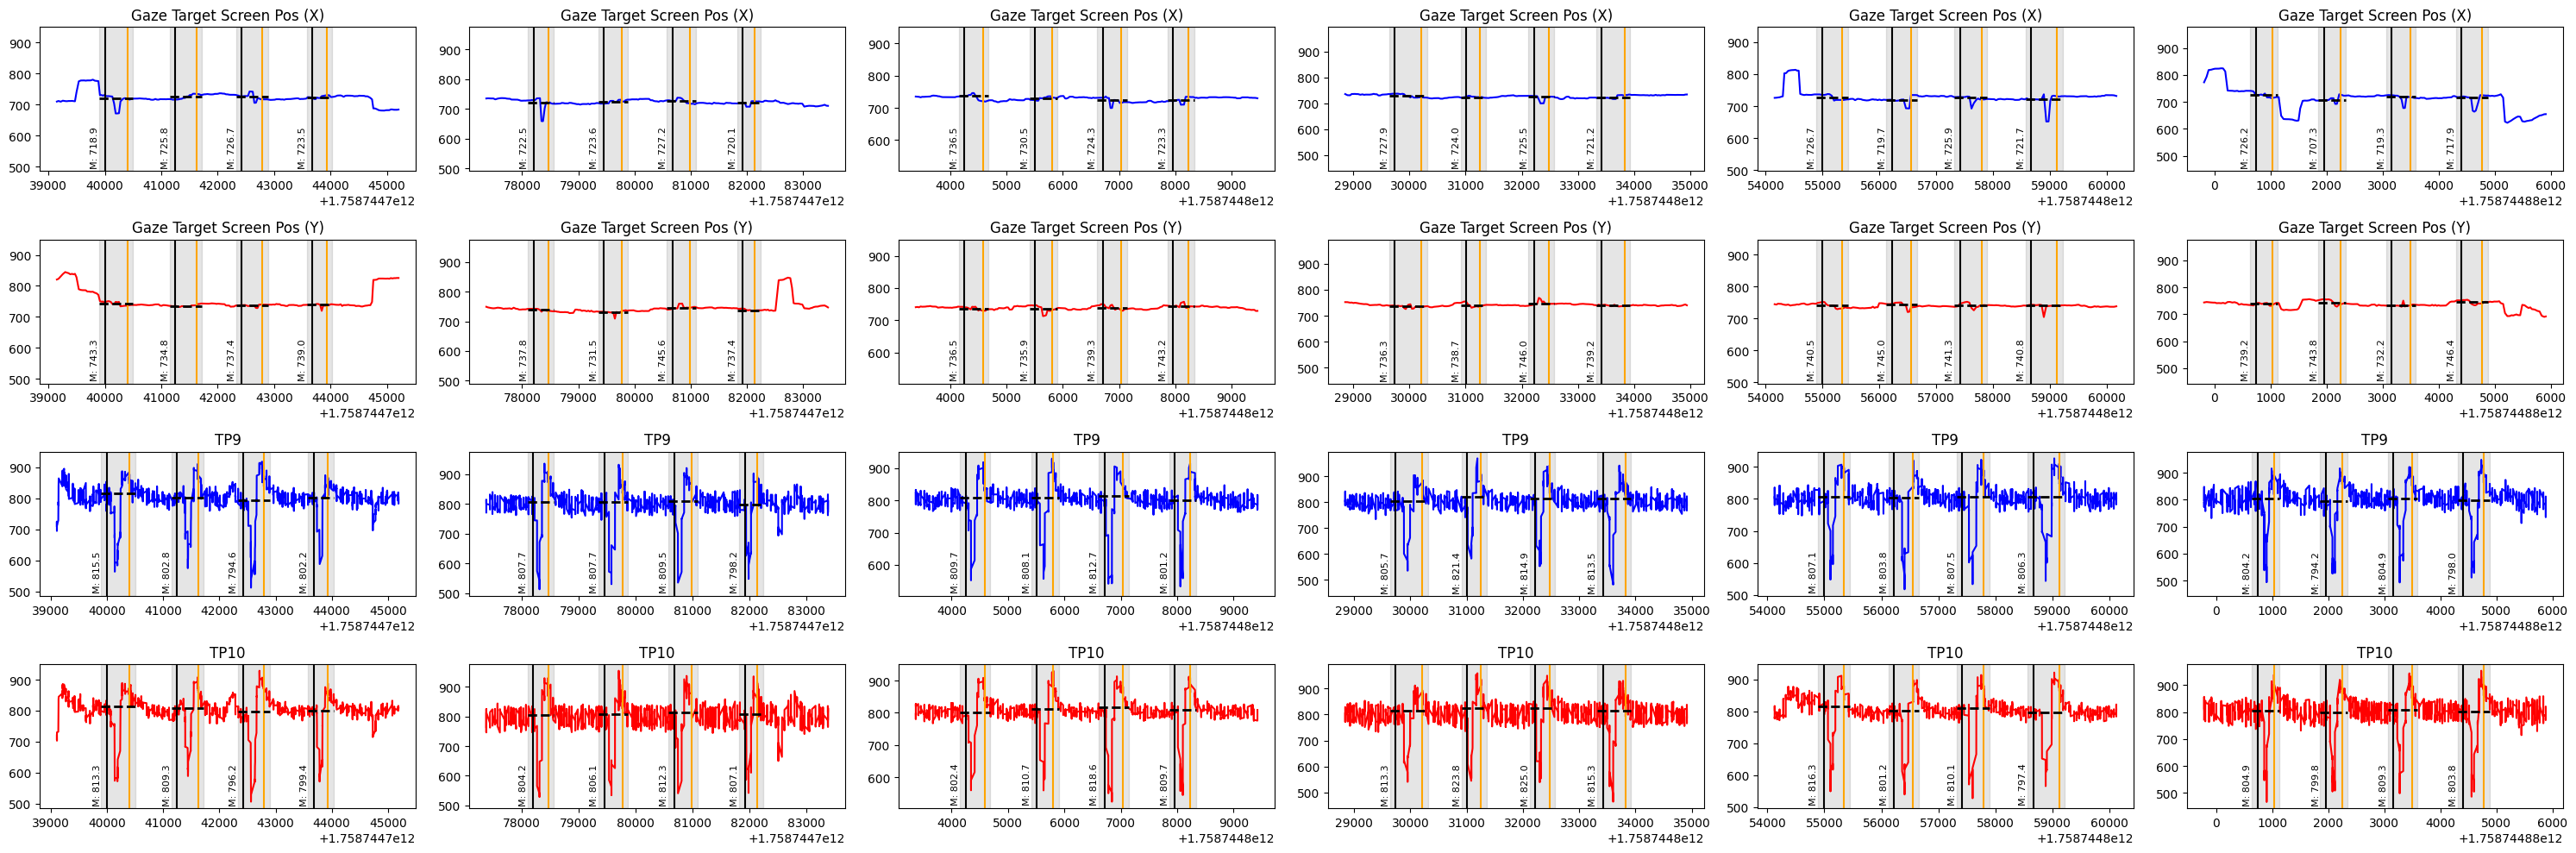

---

### Participant PI2

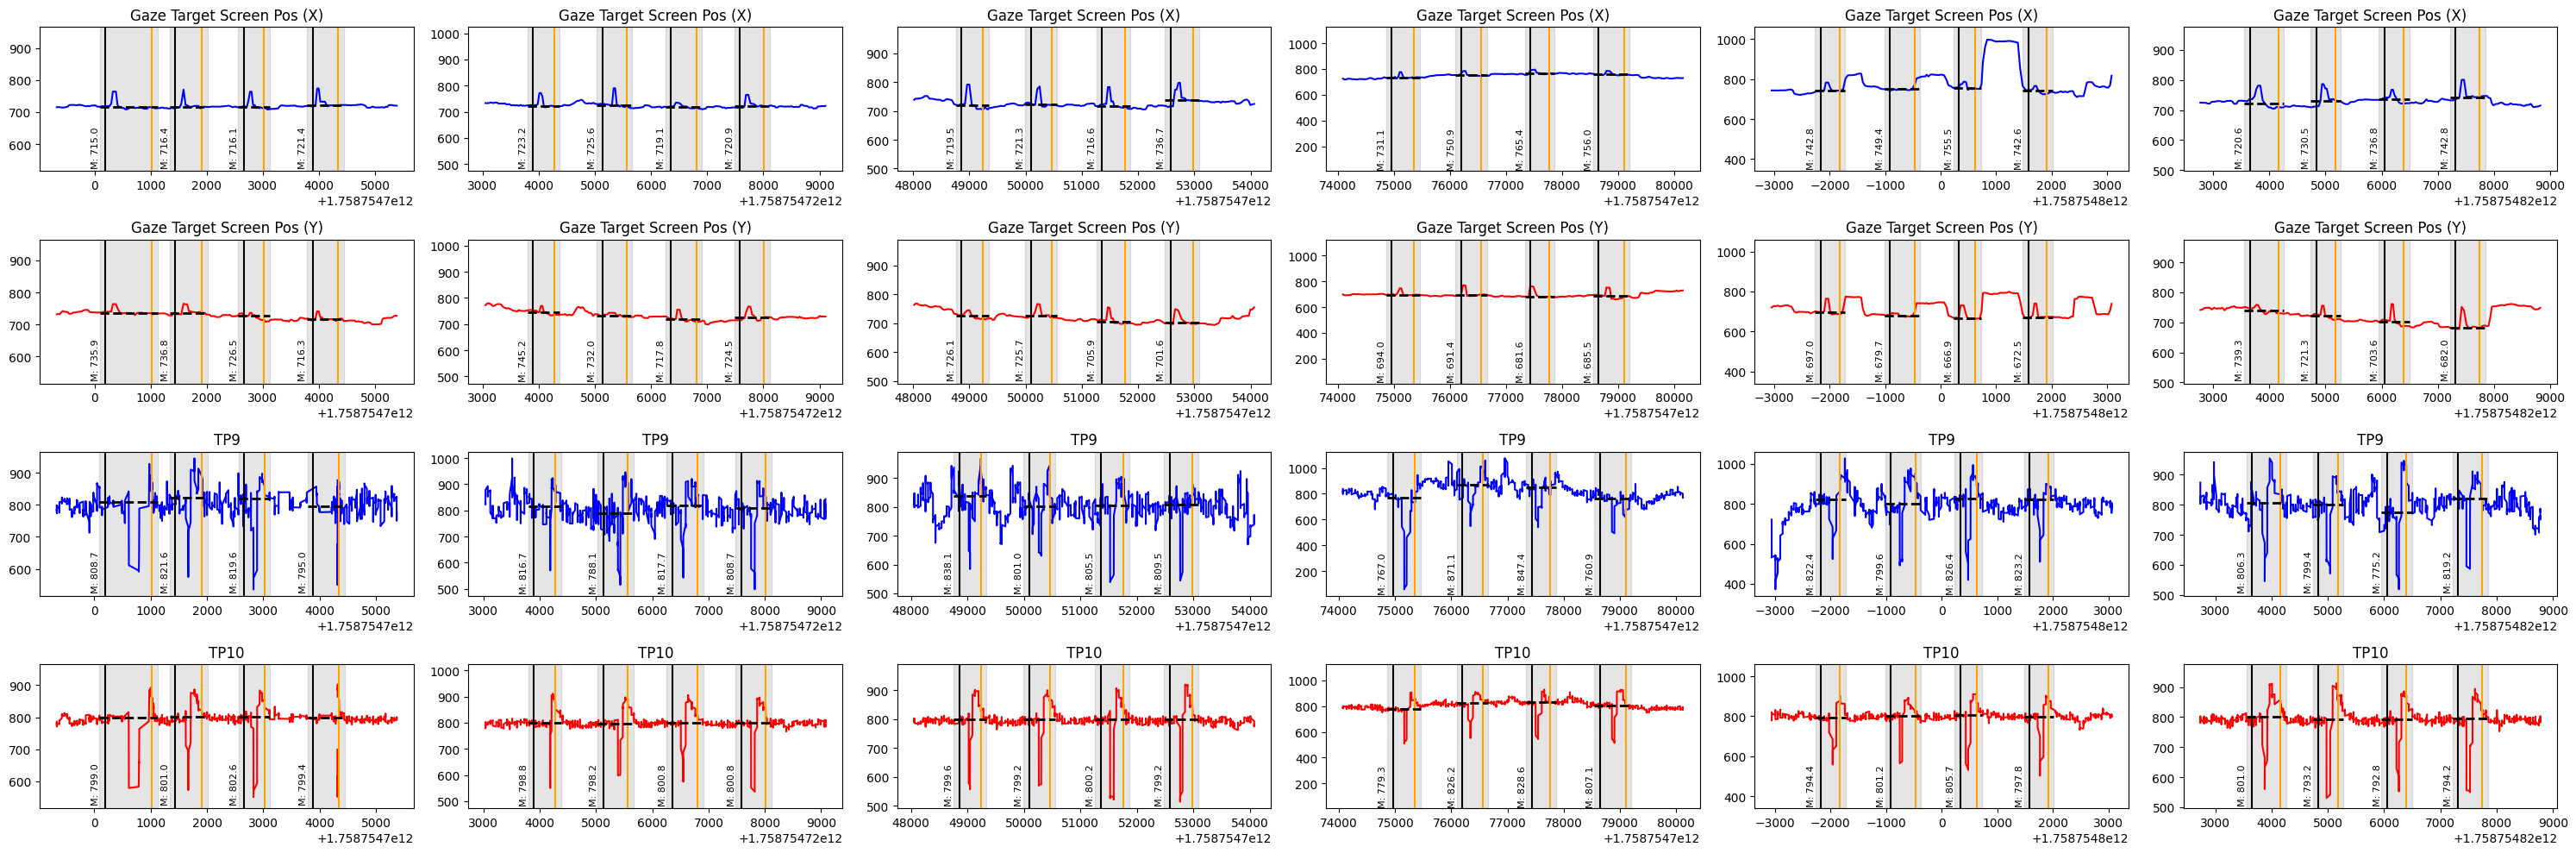

---

### Participant P3

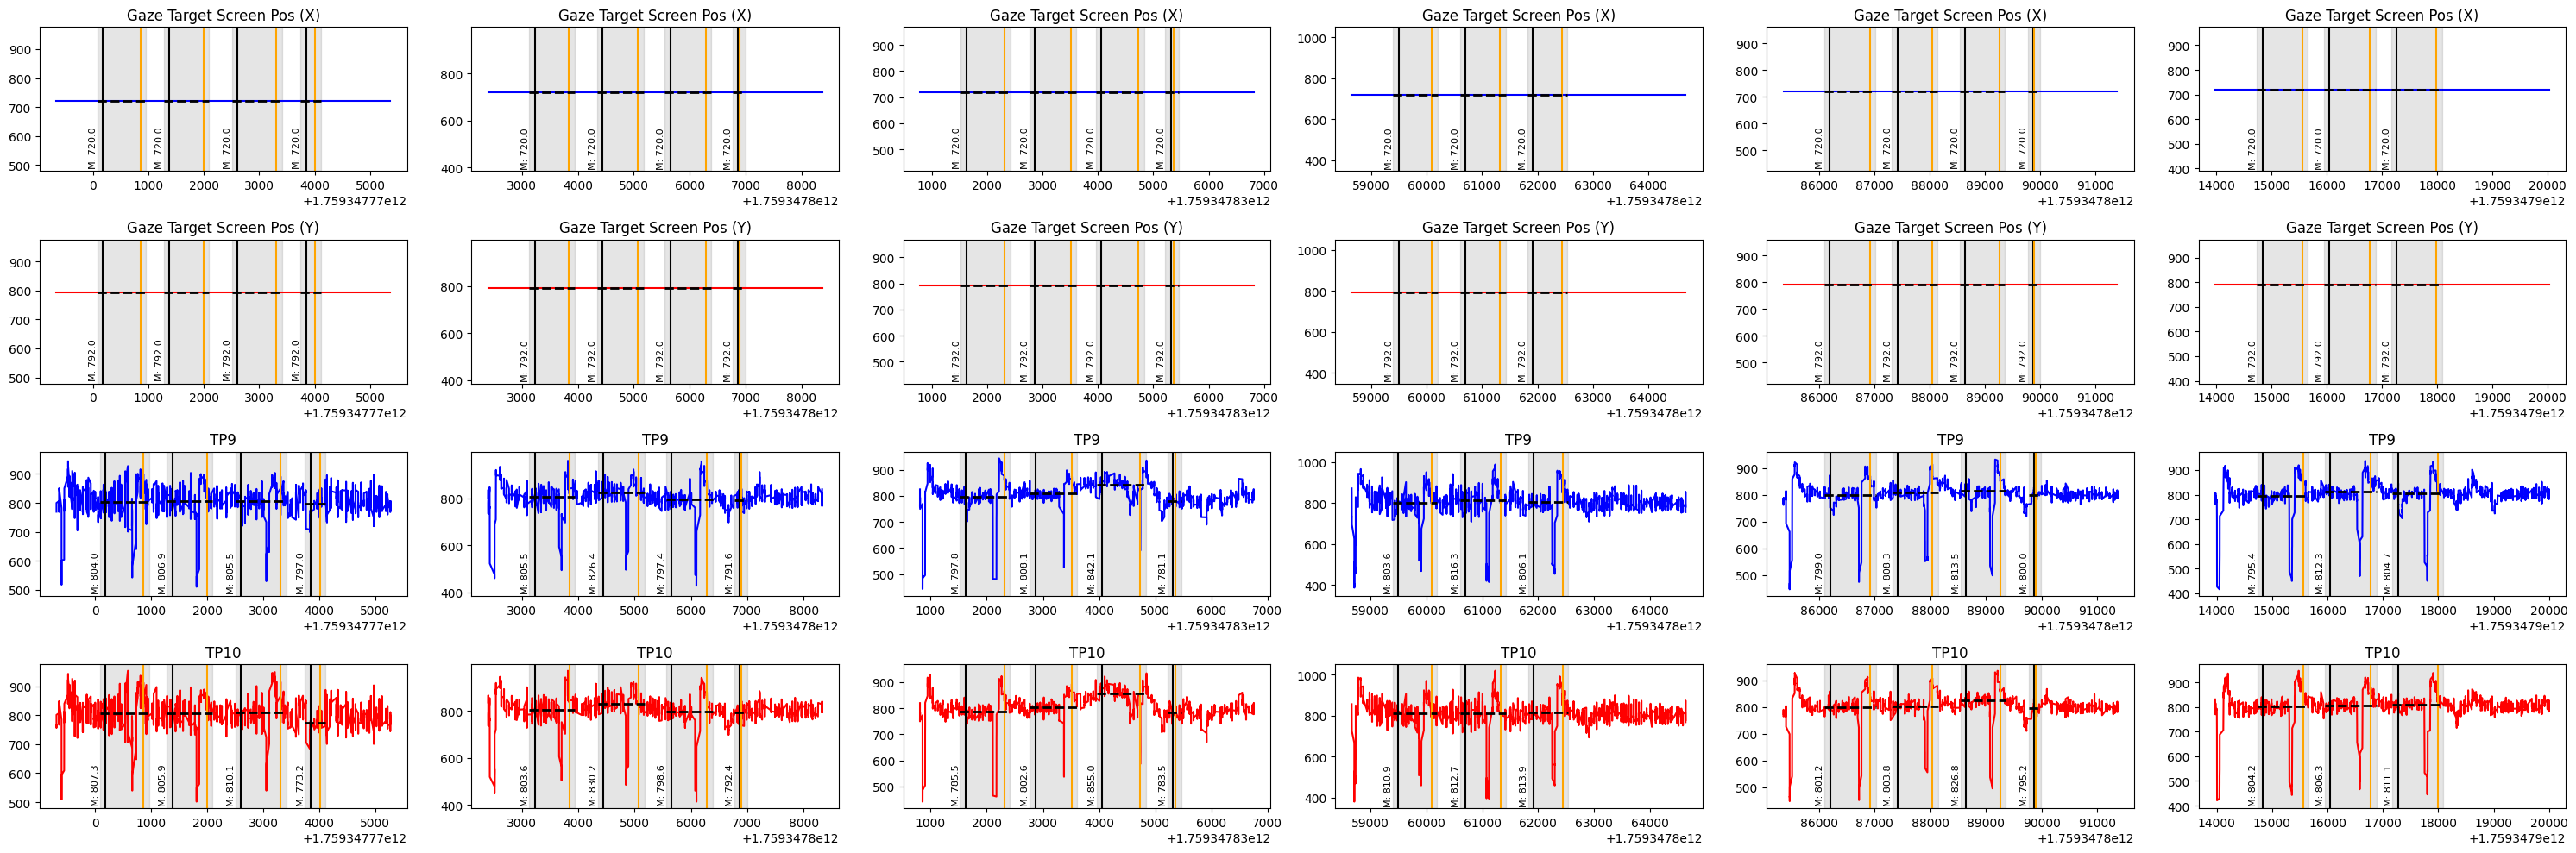

---

### Participant P4_Muse2

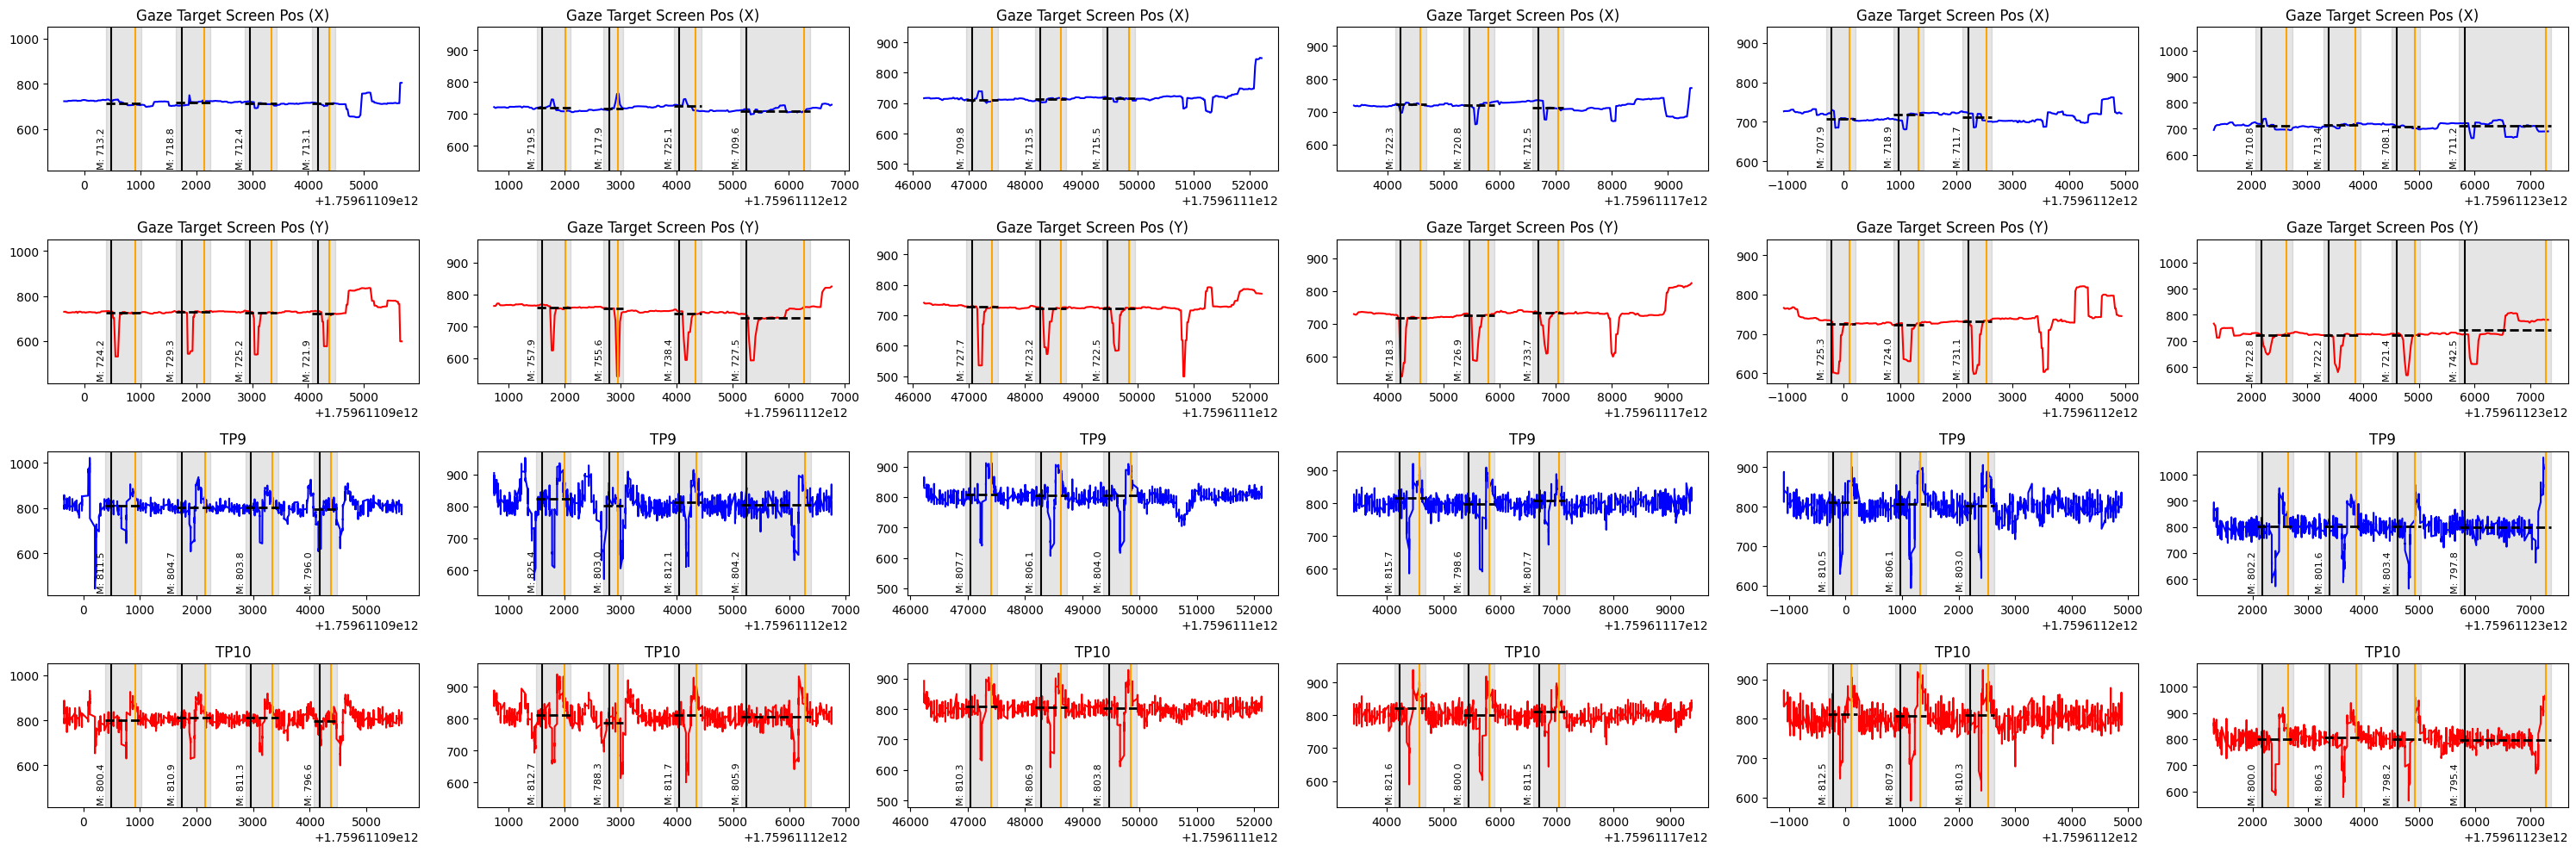

---

### Participant P5

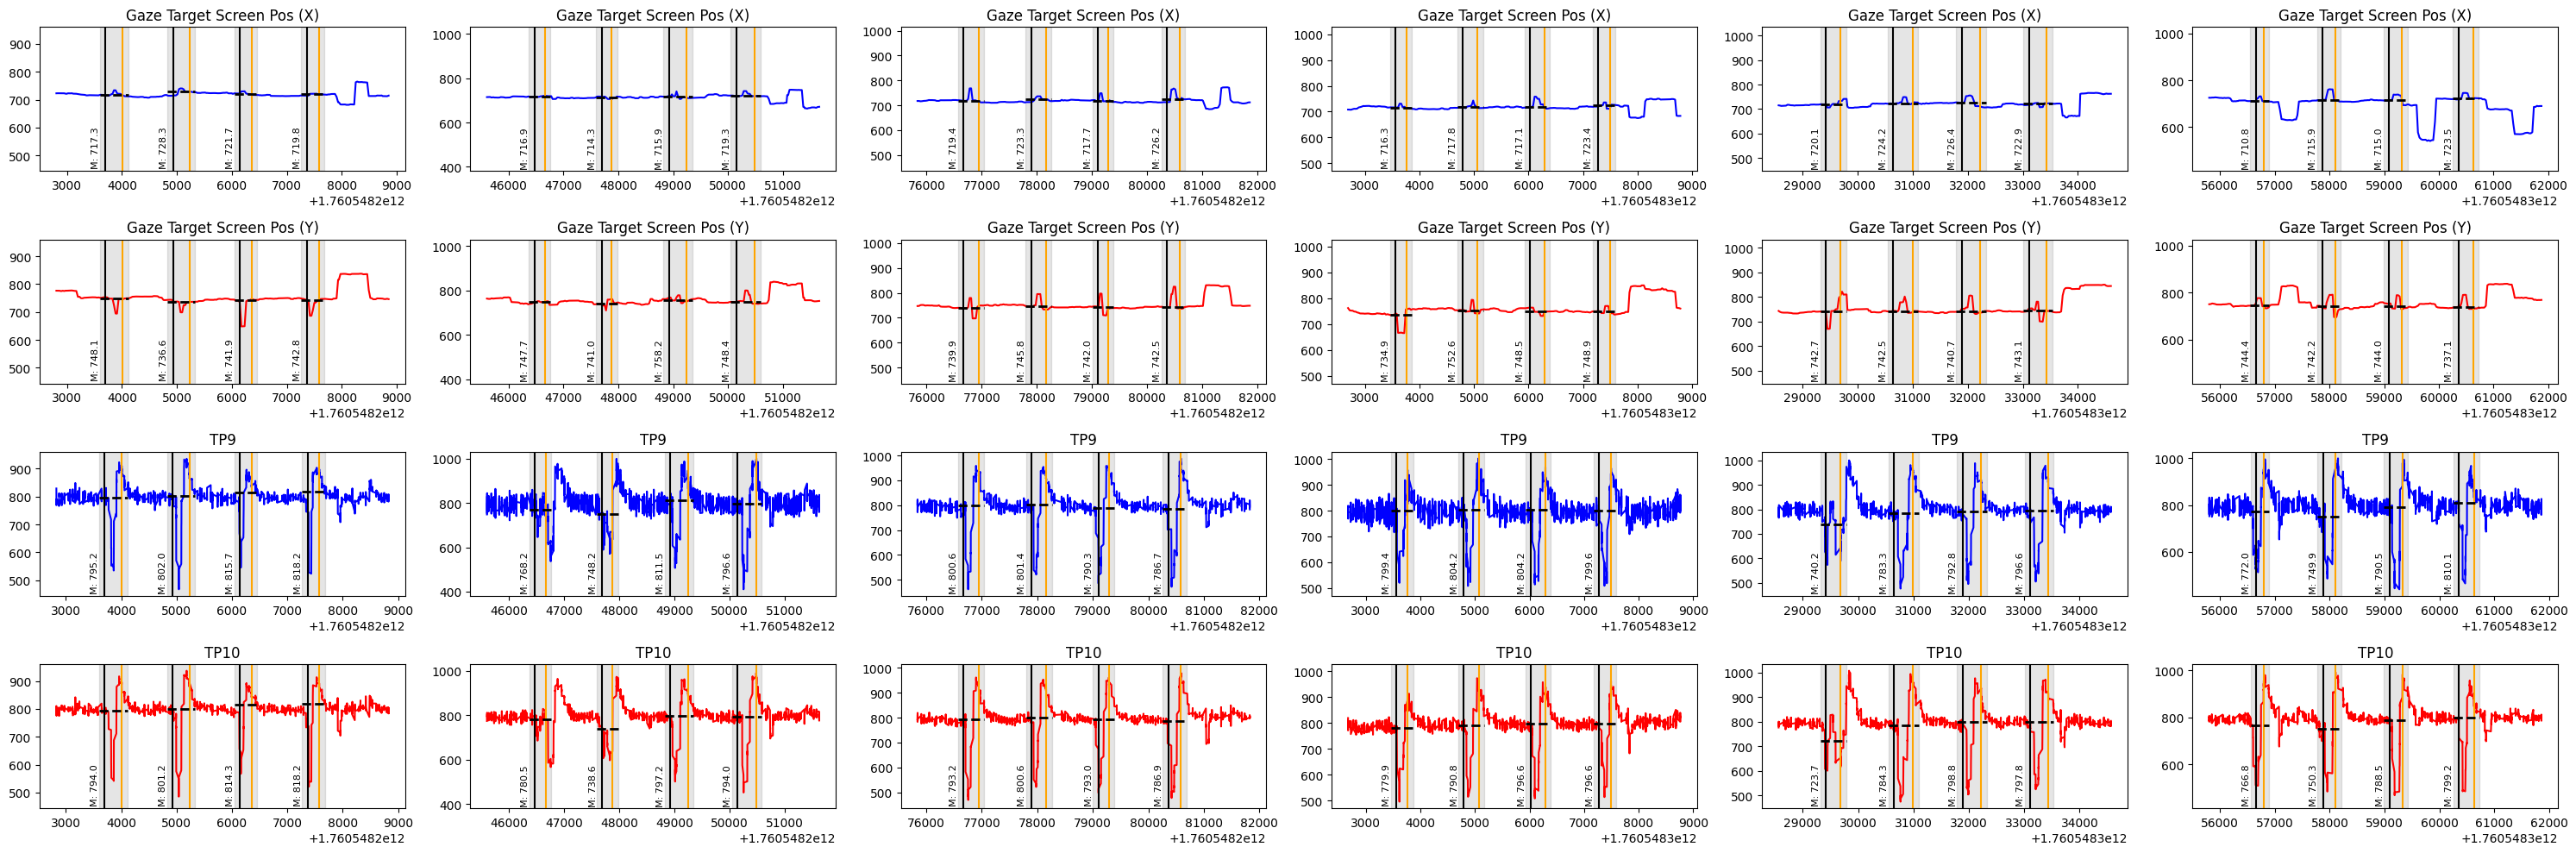

---

In [5]:
from scipy.signal import savgol_filter

# Produce a single figure to visualize all trials
# Each trial has 4 rows: `gaze x`, `gaze_y`, `TP9`, and `TP10`
# Each participant has T number of columns / trials (expected: 6) 

_SAVE_DIR = './docs/'

for p in participants:
    
    # Generate the figure
    fig, axes = plt.subplots(4, len(p['trials']), figsize=(30,10), sharey='col')

    for i in range(len(p['trials'])):
        # i = row index
        trial = p['trials'][i]

        # Read the `eeg_raw`, `eye.csv`, and `calibration.csv` files of the calibration file
        eeg = pd.read_csv(os.path.join(trial['d'], 'eeg_raw.csv')).drop(columns=['Unnamed: 0'])
        eye = pd.read_csv(os.path.join(trial['d'], 'eye.csv')).drop(columns=['Unnamed: 0'])
        cdf = pd.read_csv(os.path.join(trial['d'], 'calibration_blinks.csv'))

        # One mod: we filter out the first 5 seconds
        eeg_first_timestamp = eeg['unix_ms'].iloc[0]
        eeg_last_timestamp = eeg['unix_ms'].iloc[-1]
        eeg = eeg[eeg['unix_ms'].between(eeg_first_timestamp + 5000.0, eeg_last_timestamp - 500)]
        eye_first_timestamp = eye['unix_ms'].iloc[0]
        eye_last_timestamp = eye['unix_ms'].iloc[-1]
        eye = eye[eye['unix_ms'].between(eye_first_timestamp + 5000.0, eye_last_timestamp - 500)]

        # produce a plot line for each of the features
        # Plots 1 and 2: `gaze_target_screen_pos_x` and `gaze_target_screen_pos_y`
        x1 = eye['unix_ms'].to_list()
        y1 = eye['gaze_target_screen_pos_x'].to_list()
        y2 = eye['gaze_target_screen_pos_y'].to_list()
        plot_line(x1, y1, axes[0][i], _color='blue', _title='Gaze Target Screen Pos (X)')
        plot_line(x1, y2, axes[1][i], _color='red', _title='Gaze Target Screen Pos (Y)')

        # Plots 3 and 4: EEG TP9 and TP10
        x2 = eeg['unix_ms'].to_list()
        y3 = eeg['TP9'].to_list()
        # y3s = savgol_filter(y3, window_length=_EEG_WINDOW_LENGTH, polyorder=_EEG_POLYORDER, mode='nearest')
        y4 = eeg['TP10'].to_list()
        # y4s = savgol_filter(y4, window_length=_EEG_WINDOW_LENGTH, polyorder=_EEG_POLYORDER, mode='nearest')
        plot_line(x2, y3, axes[2][i], _color='blue', _title='TP9')
        # plot_line(x2, y3s, axes[2][i], _color='blue')
        plot_line(x2, y4, axes[3][i], _color='red', _title='TP10')
        # plot_line(x2, y4s, axes[3][i], _color='red')

        for _, row in cdf.iterrows():
            axes[0][i].axvline(x=row['overlap_unix_ms'], c='black')
            axes[1][i].axvline(x=row['overlap_unix_ms'], c='black')
            axes[2][i].axvline(x=row['overlap_unix_ms'], c='black')
            axes[3][i].axvline(x=row['overlap_unix_ms'], c='black')
            axes[0][i].axvline(x=row['blink_unix_ms'], c='orange')
            axes[1][i].axvline(x=row['blink_unix_ms'], c='orange')
            axes[2][i].axvline(x=row['blink_unix_ms'], c='orange')
            axes[3][i].axvline(x=row['blink_unix_ms'], c='orange')
            axes[0][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)
            axes[1][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)
            axes[2][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)
            axes[3][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.1)

            # Calculations
            eye_range = eye[eye['unix_ms'].between(row['start_unix_ms'], row['end_unix_ms'])]
            x_mean = round(eye_range['gaze_target_screen_pos_x'].median(), 1)
            y_mean = round(eye_range['gaze_target_screen_pos_y'].median(), 1)
            eeg_range = eeg[eeg['unix_ms'].between(row['start_unix_ms'], row['end_unix_ms'])]
            tp9_mean = round(eeg_range['TP9'].median(), 1)
            tp10_mean = round(eeg_range['TP10'].median(), 1)

            # Plot the calculations as text
            axes[0][i].text(row['start_unix_ms']-150, axes[0][i].get_ylim()[0]+10, f"M: {x_mean}", rotation=90, fontsize=8, va='bottom')
            axes[1][i].text(row['start_unix_ms']-150, axes[1][i].get_ylim()[0]+10, f"M: {y_mean}", rotation=90, fontsize=8, va='bottom')
            axes[2][i].text(row['start_unix_ms']-150, axes[2][i].get_ylim()[0]+10, f"M: {tp9_mean}", rotation=90, fontsize=8, va='bottom')
            axes[3][i].text(row['start_unix_ms']-150, axes[3][i].get_ylim()[0]+10, f"M: {tp10_mean}", rotation=90, fontsize=8, va='bottom')

            # Draw the line represnting the mean
            axes[0][i].plot((row['start_unix_ms'], row['end_unix_ms']), (x_mean, x_mean), '--', c='black', linewidth=2)
            axes[1][i].plot((row['start_unix_ms'], row['end_unix_ms']), (y_mean, y_mean), '--', c='black', linewidth=2)
            axes[2][i].plot((row['start_unix_ms'], row['end_unix_ms']), (tp9_mean, tp9_mean), '--', c='black', linewidth=2)
            axes[3][i].plot((row['start_unix_ms'], row['end_unix_ms']), (tp10_mean, tp10_mean), '--', c='black', linewidth=2)

    # Tight Layouts
    plt.tight_layout()

    # Save the image for reference later
    plt.savefig(os.path.join(_SAVE_DIR, f"{p['p']}_Eye-EEG.png"), bbox_inches='tight', dpi=300) 

    # Show things
    display(Markdown(f"### Participant {p['p']}"))
    plt.show()
    display(Markdown('---'))

From my observations:

- P1's data is no good. The screen pos y is not good for anything
- **PI2's** data shows promise, but we should be looking at **peaks** instead of valleys
- P3's data is no good. The eye tracker bugged out then
- **P4_Muse2's** data is a strong candidate in the screen pos y. We should be looking at **valleys**.
- **P5's** data is viable in certain circumstances. Both **valleys** and **peaks** are viable, depending on the trial.

the following trials appear to be good candidates for analysis. The method of determining which trials are viable... is honestly a very manual one where we literally print out the charts and visually determine that, if there's a VISIBLE pattern/peak/valley, then it's marked for approval. Any EEG or eye data that is ambivalent in its visible pattern are thrown out. 

- `PI2`:
    - **Trial #1**: Overlaps 1 and 2 | Peaks
    - **Trial #2**: Overlaps 1, 3, and 4 | Peaks
    - **Trial #3**: All overlaps | Peaks
    - **Trial #4**: All overlaps | Peaks
    - **Trial #5**: Overlaps 1, 3, and 4 | Peaks
    - **Trial #6**: Overlaps 2, 3, and 4 | Peaks
- `P4_Muse2`:
    - **Trial #1**: All Overlaps | Valleys
    - **Trial #2**: Overlaps 1, 2, and 3 | Valleys
    - **Trial #3**: Overlaps 1, 2, and 3 | Valleys
    - **Trial #4**: Overlaps 1, 2, and 3 | Valleys
    - **Trial #5**: Overlaps 1, 2, and 3 | Valleys
    - **Trial #6**: Overlaps 1, 2, and 3 | Valleys
- `P5`:
    - **Trial #1**: All overlaps | Valleys
    - **Trial #2**: Overlap 4 | Peak
    - **Trial #3**: All overlaps | Peaks
    - **Trial #4**: Overlaps 1 (Valley), 2 (Peak), and 4 (Peak)
    - **Trial #5**: Overlaps 1 (Valley), 2 (Peak), 3 (Peak), and 4 (Peak)
    - **Trial #6**: All overlaps | Peaks

Let's save this into a JSON object so that we can store it as a combined scheme for later.

In [6]:
import json

cal_blink_trials = [
    {
        'p':'PI2',
        'trials':[
            {
                'trial_id':1,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':2, 'type':'peak' }
                ]
            },
            {
                'trial_id':2,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':3,
                'overlaps': [
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':4,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':5,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':6,
                'overlaps':[
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            }
        ]
    },
    {
        'p':'P4_Muse2',
        'trials':[
            {
                'trial_id':1,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                    { 'overlap_counter':4, 'type':'valley' }
                ]
            },
            {
                'trial_id':2,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                ]
            },
            {
                'trial_id':3,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                ]
            },
            {
                'trial_id':4,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                ]
            },
            {
                'trial_id':5,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                ]
            },
            {
                'trial_id':6,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                ]
            }
        ]
    },
    {
        'p':'P5',
        'trials':[
            {
                'trial_id':1,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'valley' },
                    { 'overlap_counter':3, 'type':'valley' },
                    { 'overlap_counter':4, 'type':'valley' }
                ]
            },
            {
                'trial_id':2,
                'overlaps':[
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':3,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':4,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':5,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'valley' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            },
            {
                'trial_id':6,
                'overlaps':[
                    { 'overlap_counter':1, 'type':'peak' },
                    { 'overlap_counter':2, 'type':'peak' },
                    { 'overlap_counter':3, 'type':'peak' },
                    { 'overlap_counter':4, 'type':'peak' }
                ]
            }
        ]
    }
]

savefile = "./data/blink_alignment_trials.json"
with open(savefile, "w") as json_file:
    json.dump(cal_blink_trials, json_file, indent=2)

## Step 2: Calculating Peaks and Valleys

We've now generated our file data in `./data/blink_alignment_trials.json` file. This tells us, for which participants, which trials and overlaps therein we should use. Now, let's read this file, look at their respective trial data, and proceed with peak/valley analysis.

To achieve the peak and valley analysis, we need an algorithm. The primary algorithm we'll use is `scipy`'s [`find_peaks()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) algorithm. To achieve valleys, we can just invert the signal.

### 2a. Read our data

In [7]:
# Cal Blink TrialS. Since there's technically a variable with this name in an above block, we abbreviate the name for the imported variable
with open('./data/blink_alignment_trials.json') as json_file:
    cbts = json.load(json_file)

for p in cbts:
    display(Markdown(f"#### {p['p']}:"))
    for t in p['trials']:
        display(Markdown(f"##### {t['trial_id']}:"))
        display(t['overlaps'])

#### PI2:

##### 1:

[{'overlap_counter': 1, 'type': 'peak'},
 {'overlap_counter': 2, 'type': 'peak'}]

##### 2:

[{'overlap_counter': 1, 'type': 'peak'},
 {'overlap_counter': 3, 'type': 'peak'},
 {'overlap_counter': 4, 'type': 'peak'}]

...

[{'overlap_counter': 1, 'type': 'valley'},
 {'overlap_counter': 2, 'type': 'peak'},
 {'overlap_counter': 4, 'type': 'peak'}]

##### 5:

[{'overlap_counter': 1, 'type': 'valley'},
 {'overlap_counter': 2, 'type': 'peak'},
 {'overlap_counter': 3, 'type': 'peak'},
 {'overlap_counter': 4, 'type': 'peak'}]

##### 6:

[{'overlap_counter': 1, 'type': 'peak'},
 {'overlap_counter': 2, 'type': 'peak'},
 {'overlap_counter': 3, 'type': 'peak'},
 {'overlap_counter': 4, 'type': 'peak'}]

### 2b. Hard part: calculations

Now that we've imported the data properly, let's actually look at each overlap, each trial.

In [8]:
from scipy.signal import find_peaks

cbts_results_list = []
for p in cbts:

    # Iterate through each trial
    for t in p['trials']:
        
        # What's the trial ID?
        trial_id = t['trial_id']

        # What's the directory to this calibration directory?
        cdir = f"./data/{p['p']}/trials/{trial_id}/calibration/"

        # Read the calibrations involved
        cdf = pd.read_csv(os.path.join(cdir, "calibration_blinks.csv"))

        # Each overlap record is a dictionary with the following properties: `overlap_counter` (1-4) and `type` ('peak', 'valley')
        # We can create a dataframe since all overlaps have a common structure
        odf = pd.DataFrame(t['overlaps'])

        # We do a left merge, with the left = odf and right = cdf
        to_check = pd.merge(left=odf, right=cdf, on='overlap_counter', how='left')
        to_check.insert(0, "p_id", p['p'])
        to_check.insert(1, "trial_id", trial_id)

        # We need to read the eeg_raw and eye data of this calibration directory
        eeg = pd.read_csv(os.path.join(cdir, 'eeg_raw.csv')).drop(columns=['Unnamed: 0'])
        eye = pd.read_csv(os.path.join(cdir, 'eye.csv')).drop(columns=['Unnamed: 0'])

        # For each row in `to_check`, we extract the relevant eeg and eye data. Then, depending on the type, we extract either the peak or valley of the `eye_y` data and the valley of the TP9 and TP10.
        to_append = []
        for _, row in to_check.iterrows():
            _eeg = eeg[eeg['unix_ms'].between(row['start_unix_ms'], row['blink_unix_ms'])]
            _eye = eye[eye['unix_ms'].between(row['start_unix_ms'], row['blink_unix_ms'])]

            # valley of TP9 and TP10, get the smallest valley
            _eeg_x = _eeg['unix_ms'].to_list()
            tp9 = _eeg['TP9'].to_list()
            tp10 = _eeg['TP10'].to_list()
            tp9_valley_indices, _ = find_peaks([v*-1 for v in tp9], prominence=2)
            tp9_valleys = [[_eeg_x[i], tp9[i]] for i in tp9_valley_indices]
            tp10_valley_indices, _ = find_peaks([v*-1 for v in tp10], prominence=2)
            tp10_valleys = [[_eeg_x[i], tp10[i]] for i in tp10_valley_indices]
            eeg_valleys = tp9_valleys + tp10_valleys
            sorted_eeg_valleys = sorted(eeg_valleys, key=lambda x: x[1])
            eeg_valley = sorted_eeg_valleys[0]

            # either peak or valley of eye, get either the highest peak or the smallest valley
            _eye_x = _eye['unix_ms'].to_list()
            _eye_y = _eye['gaze_target_screen_pos_y'].to_list()
            # if we want valleys, then we invert to find the "peaks"
            if (row['type'] == 'valley'):   
                _eye_y2 = [v*-1 for v in _eye_y]
            else:
                _eye_y2 = _eye_y
            eye_y_valley_indices, eye_properties = find_peaks(_eye_y2)
            eye_dips = [[_eye_x[i], _eye_y2[i]] for i in eye_y_valley_indices]
            # if we want valleys, then we gotta sort so that the smallest value is first. Otherwise (i.e. peaks), then we find the largest value
            if (row['type'] == 'valley'):   sorted_eye_dips = sorted(eye_dips, key=lambda x: x[1], reverse=True)
            else:                           sorted_eye_dips = sorted(eye_dips, key=lambda x: x[1], reverse=True)
            eye_valley = sorted_eye_dips[0]

            # append to... `to_append`
            to_append.append({'overlap_counter':row['overlap_counter'], 'eeg_blink_x':eeg_valley[0], 'eeg_blink_y':eeg_valley[1], 'eye_blink_x':eye_valley[0], 'eye_blink_y':eye_valley[1]})

        # Append `to_append` to `to_check`
        adf = pd.DataFrame(to_append)
        to_check_results = pd.merge(left=to_check, right=adf, on='overlap_counter', how='left')
        
        # We want to save the results, so that we can visualize them later.
        cbts_results_list.append(to_check_results)

# Let's merge our results, then save to a file for later
cbts_results = pd.concat(cbts_results_list, ignore_index=True)
cbts_results.to_csv('./data/blink_alignment_results.csv', index=False)
display(cbts_results)

,p_id,trial_id,overlap_counter,type,overlap_unix_ms,blink_unix_ms,start_unix_ms,end_unix_ms,duration,eeg_blink_x,eeg_blink_y,eye_blink_x,eye_blink_y
0,PI2,1,1,peak,1758754700191,1758754701026,1758754700091,1758754701126,1035,1758754700613,579,1758754700382,764
1,PI2,1,2,peak,1758754701436,1758754701911,1758754701336,1758754702011,675,1758754701667,573,1758754701586,765
2,PI2,2,1,peak,1758754723896,1758754724278,1758754723796,1758754724378,582,1758754724187,550,1758754724066,770
3,PI2,2,3,peak,1758754726358,1758754726810,1758754726258,1758754726910,652,1758754726551,543,1758754726469,756
4,PI2,2,4,peak,1758754727584,1758754728016,1758754727484,1758754728116,632,1758754727820,498,1758754727732,767
5,PI2,3,1,peak,1758754748858,1758754749238,1758754748758,1758754749338,580,1758754749045,557,1758754748999,746
6,PI2,3,2,peak,1758754750091,1758754750458,1758754749991,1758754750558,567,1758754750263,570,1758754750206,767
7,PI2,3,3,peak,1758754751357,1758754751766,1758754751257,1758754751866,609,1758754751590,521,1758754751462,756
8,PI2,3,4,peak,1758754752580,1758754752984,1758754752480,1758754753084,604,1758754752765,514,1758754752656,749
9,PI2,4,1,peak,1758754774960,1758754775355,1758754774860,1758754775455,595,1758754775161,58,1758754775129,746


### 2c. Render Results

Let's render our results. They are saved in `./data/blink_alignment_results.csv`

### Participant PI2

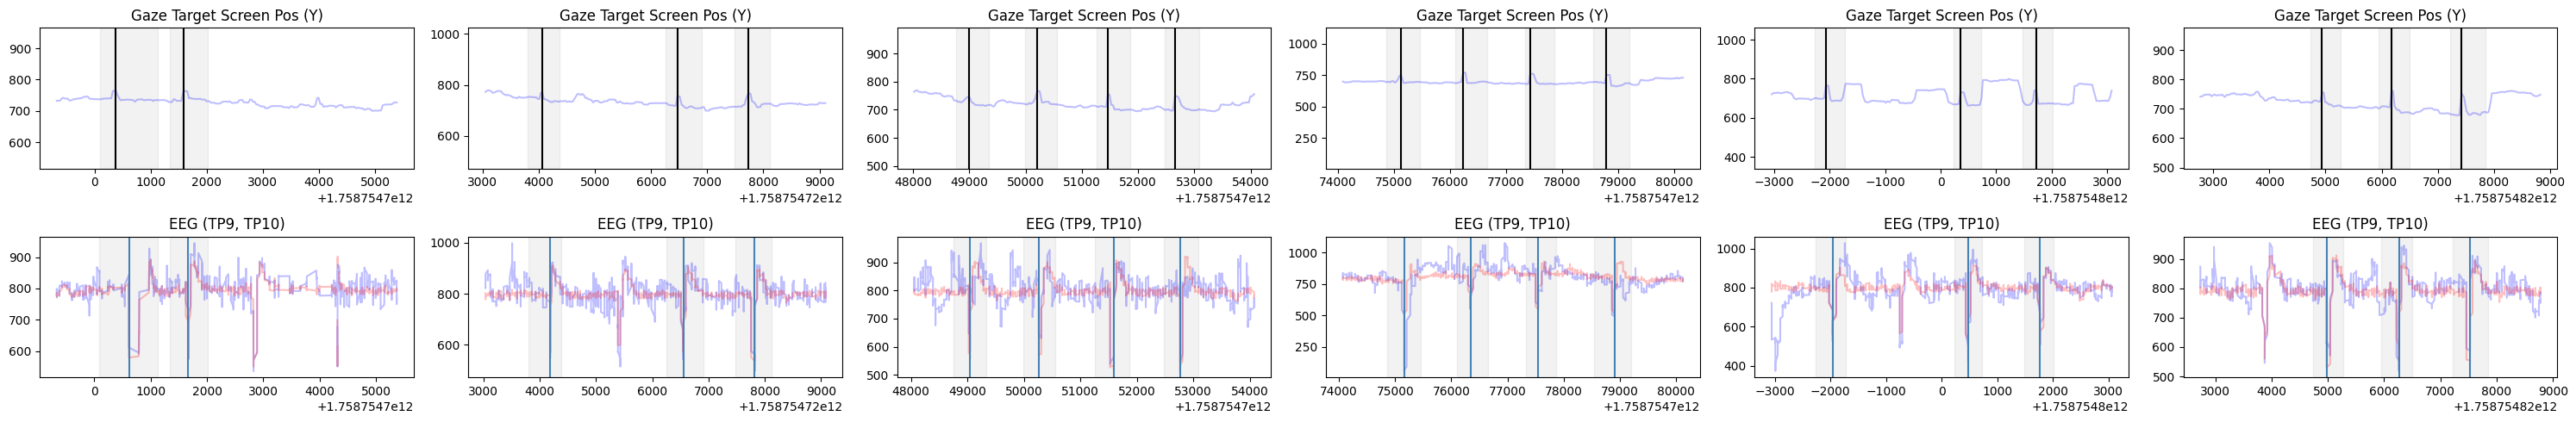

---

### Participant P4_Muse2

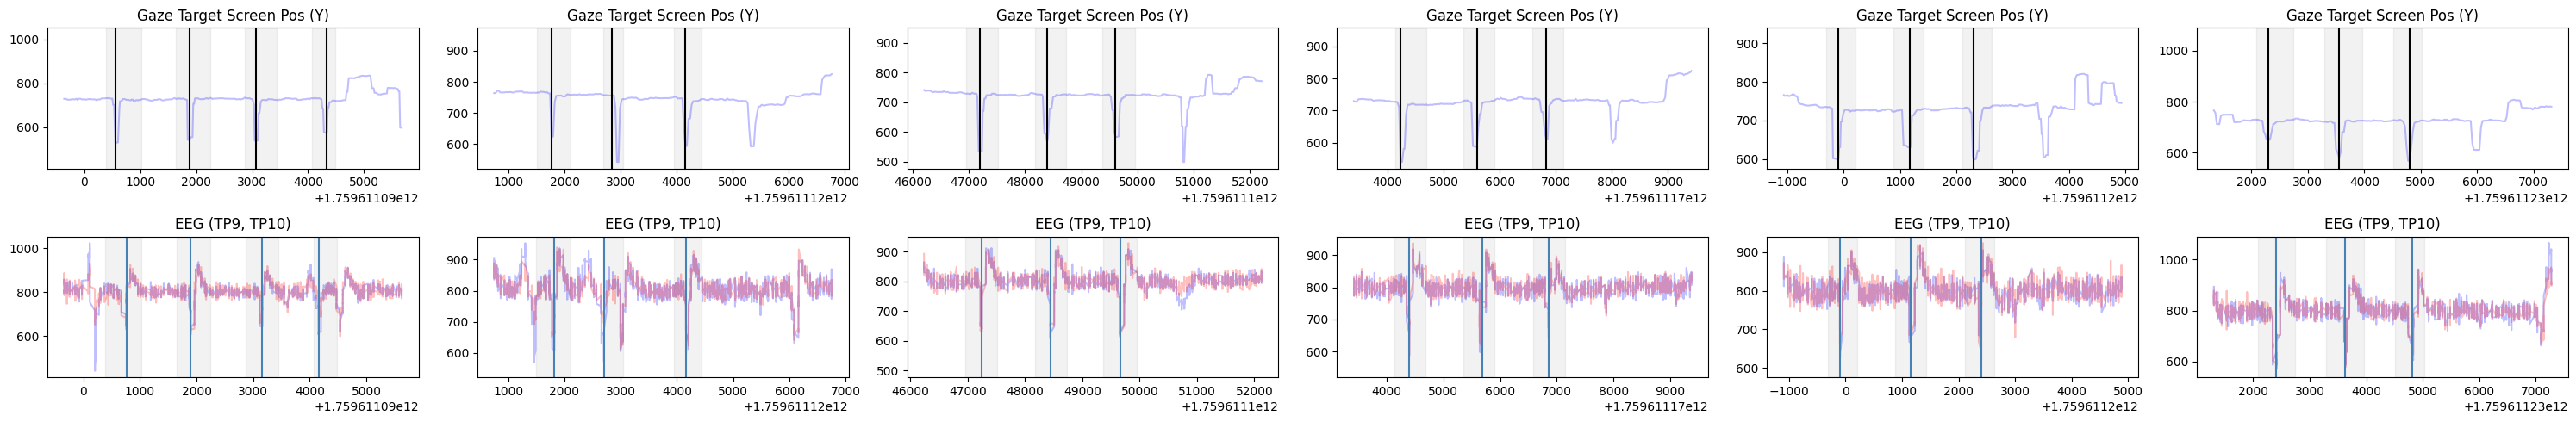

---

### Participant P5

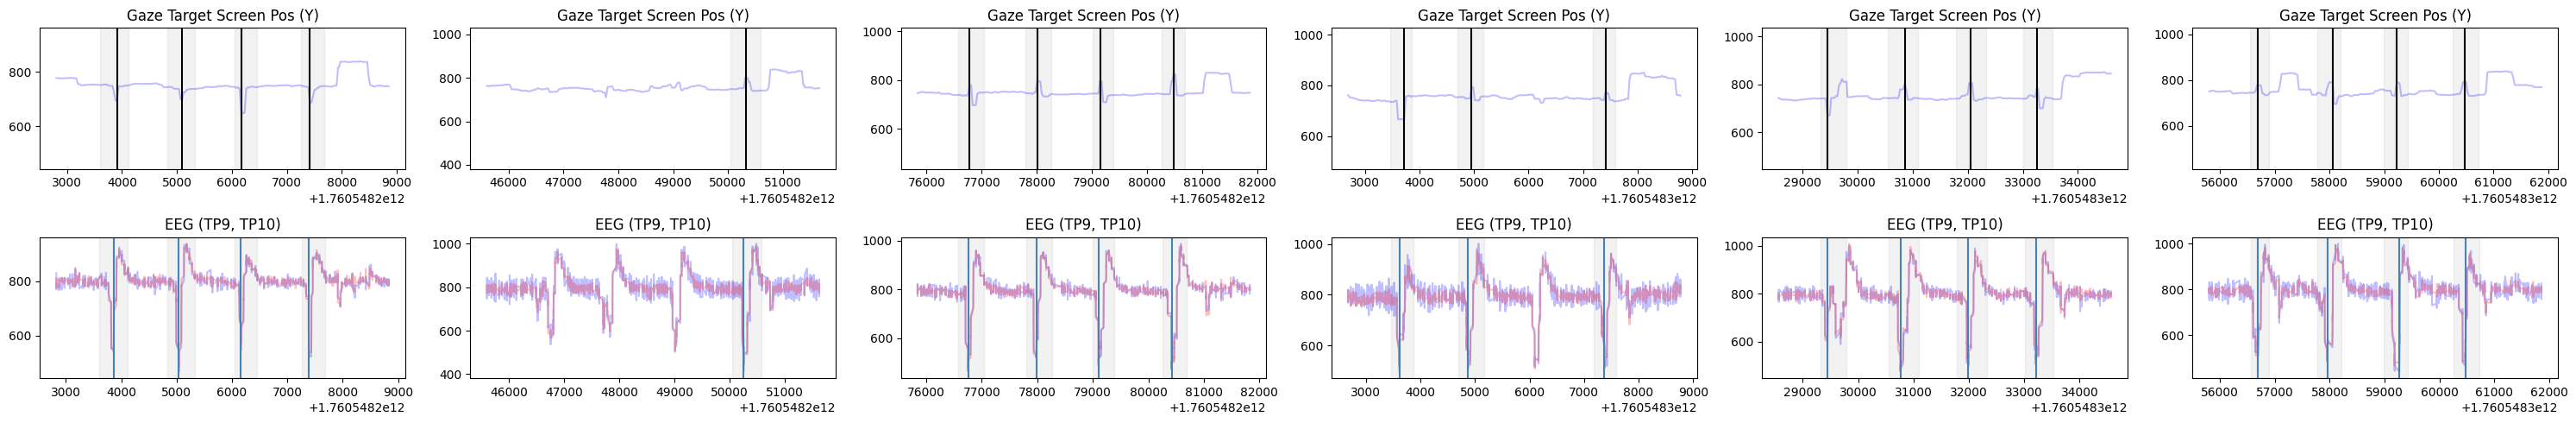

---

In [13]:
# Read our data
blink_alignment_results = pd.read_csv('./data/blink_alignment_results.csv')

# unique participants
blink_participants=  blink_alignment_results['p_id'].unique()

for p in blink_participants:

    # Extract only relevant trials to this specific participant
    df = blink_alignment_results[blink_alignment_results['p_id'] == p]

    # Get the unique trial numbers
    trial_ids = df['trial_id'].unique()
    
    # Generate the figure. 2 rows: eye and eeg (TP9 and TP10 are combined), cols = # of trials involved
    fig, axes = plt.subplots(2, len(trial_ids), figsize=(30,5), sharey='col')

    # Iterate through figure columns
    for i in range(len(trial_ids)):
        # i = column index
        trial_id = trial_ids[i]

        # Read the `eeg_raw`, `eye.csv`, and `calibration.csv` files of the calibration file
        eeg = pd.read_csv(f'./data/{p}/trials/{trial_id}/calibration/eeg_raw.csv').drop(columns=['Unnamed: 0'])
        eye = pd.read_csv(f'./data/{p}/trials/{trial_id}/calibration/eye.csv').drop(columns=['Unnamed: 0'])
        cdf = df[df['trial_id']==trial_id]

        # One mod: we filter out the first 5 seconds and the last 0.5 seconds
        eeg_first_timestamp = eeg['unix_ms'].iloc[0]
        eeg_last_timestamp = eeg['unix_ms'].iloc[-1]
        eeg = eeg[eeg['unix_ms'].between(eeg_first_timestamp + 5000.0, eeg_last_timestamp - 500)]
        eye_first_timestamp = eye['unix_ms'].iloc[0]
        eye_last_timestamp = eye['unix_ms'].iloc[-1]
        eye = eye[eye['unix_ms'].between(eye_first_timestamp + 5000.0, eye_last_timestamp - 500)]

        # produce a plot line for each of the features
        # Row 1: `gaze_target_screen_pos_y`
        x1 = eye['unix_ms'].to_list()
        y1 = eye['gaze_target_screen_pos_y'].to_list()
        plot_line(x1, y1, axes[0][i], _color='blue', _title='Gaze Target Screen Pos (Y)', _alpha=0.25)

        # Plots 2: EEG TP9 and TP10
        x2 = eeg['unix_ms'].to_list()
        tp9 = eeg['TP9'].to_list()
        tp10 = eeg['TP10'].to_list()
        plot_line(x2, tp9, axes[1][i], _color='blue', _label='TP9', _alpha=0.25)
        plot_line(x2, tp10, axes[1][i], _color='red', _label='TP10', _alpha=0.25, _title='EEG (TP9, TP10)')

        # Now render our alignment identifiers
        for _, row in cdf.iterrows():
            # The four columns we need to pay attention to: `eeg_blink_x`, `eeg_blink_y`, `eye_blink_x`, and `eye_blink_y`
            eye_x = row['eye_blink_x']
            eeg_x = row['eeg_blink_x']
            axes[0][i].axvline(x=eye_x, c='black')
            axes[1][i].axvline(x=eeg_x, c='steelblue')

            axes[0][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.05)
            axes[1][i].axvspan(xmin=row['start_unix_ms'], xmax=row['end_unix_ms'], color='black', alpha=0.05)

    # Tight Layouts
    plt.tight_layout()

    """
    # Save the image for reference later
    plt.savefig(os.path.join(_SAVE_DIR, f"{p['p']}_Eye-EEG.png"), bbox_inches='tight', dpi=300) 
    """

    # Show things
    display(Markdown(f"### Participant {p}"))
    plt.show()
    display(Markdown('---'))

## Step 3: Calculating Offsets

We've visually validated that the data seems to be working, at least for most trials. let's proceed with actually graphing all the offsets in a box plot.

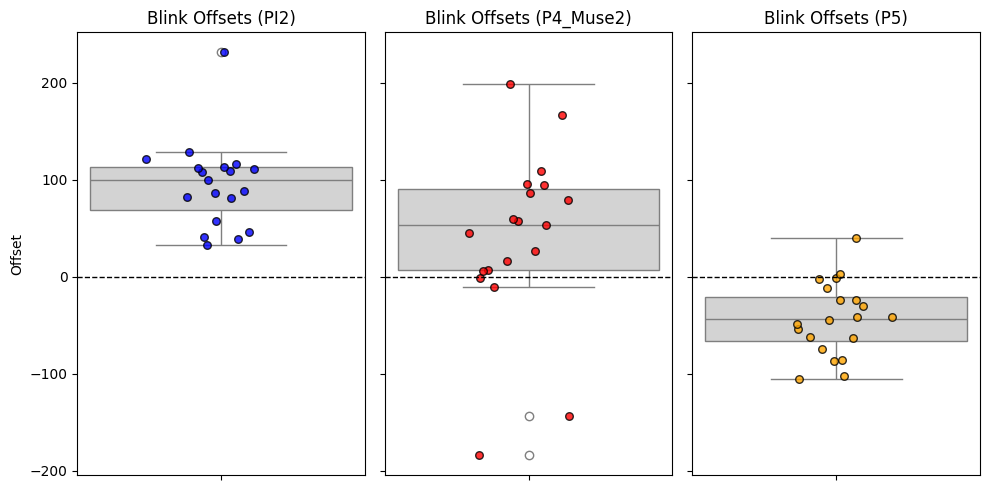

In [10]:
import seaborn as sns

_PARTICIPANT_COLORS = {
    'PI2':'blue',
    'P4_Muse2':'red',
    'P5':'orange'
}

# Read our data
blink_alignment_results = pd.read_csv('./data/blink_alignment_results.csv')

# For each row, calculate the timing offset from the eeg blink to the eye blink
blink_alignment_results['offset'] = blink_alignment_results['eeg_blink_x'] - blink_alignment_results['eye_blink_x']

# Let's render in a boxplot
fig, axes = plt.subplots(1,3, figsize=(10, 5), sharey='row')

# Divide based on participant
p_ids = blink_alignment_results['p_id'].unique()

# Loop through to render
for i in range(len(p_ids)):
    p = p_ids[i]
    pc = _PARTICIPANT_COLORS[p]
    subdf = blink_alignment_results[blink_alignment_results['p_id'] == p]
    
    # plot boxplot
    sns.boxplot(y="offset", data=subdf, ax=axes[i], color="lightgray", width=0.3, zorder=1)

    # --- Overlay the points ---
    x_jitter = np.random.normal(loc=0, scale=0.03, size=len(subdf))
    axes[i].scatter(
        x=x_jitter,
        y=subdf["offset"],
        color=pc,
        s=30, alpha=0.8, edgecolor="black",
        zorder=2
    )

    # Render a black line to represent 0
    axes[i].axhline(y=0, c='black', linewidth=1, linestyle='--')

    axes[i].set_title(f"Blink Offsets ({p})")
    axes[i].set_ylabel("Offset")

# Render
plt.tight_layout()
plt.show()

# Save our offset data
blink_alignment_results.to_csv('./data/blink_alignment_offsets.csv', index=False)

## Findings

This is genuinely interesting! It appears that for a majority of people, the offsets do ineed appear to be **consistent**. However, for some reason, P5's offsets are in the _negatives_, meaning that the eye movement for P5 was recorded AFTER the eeg detected the blink. This could suggest either **lag** or a **delay** in the eye data. I make this assumption because PI2 and P4_Muse2 both have offsets that are _positive_.

The main excursion of this exercise has been achieved. I am pretty satisfied to state the following:

1. Each participant has to have the delay between EEG blink and the eye tracking blink that is unique to that circumstance. It doesn't seem to be a consistent delay.
2. To calculate the offset, we can extrapolate the median of the offsets and subtract the EEG data using that median offset.
    - If the EEG blinks occur AFTER the eye blink (expected), then if we do `EEG TIMESTAMP` - `MEDIAN` (here, `MEDIAN` is a positive value), then we'll have the eeg and eye data aligned.
    - Alternatively, if the EEG blinks occur BEFORE the eye blink (unexpected), then we can STILL do `EEG TIMESTAMP` - `MEDIAN`. This is because `EEG TIMESTAMP` - `EYE TIMESTAMP` results in a _negative_ median value. Thereby, `EEG TIMESTAMP - (negative value)` will actually push the EEG data up to match the eye data.

## Step 4: Saving Our Offsets

This one's rather simple. Let's generate an output `./data/valid_participants.csv` that contains 1) which participants' datasets are valid to use, and 2) what the measured median offset is.

In [147]:
blink_alignment_offsets = pd.read_csv('./data/blink_alignment_offsets.csv')
offset_medians = blink_alignment_offsets.groupby('p_id', as_index=False)['offset'].median()
offset_medians.to_csv('./data/valid_participant_offsets.csv', index=False)

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[blink_signals.ipynb](./blink_signals.ipynb)|<i>alignment.ipynb</i>|[cleanup.ipynb](./cleanup.ipynb)|

We still need to do some VERY minor cleanup, so let's hop on over to [cleanup.ipynb](./cleanup.ipynb). This notebook will help make sure that `positions.csv` has `unix_ms` alongside each frame, among other minor things.

---

## MISCELLANEOUS

The boxes below are purely miscellaneous in their application. Consider them by-products of an earlier version of the analysis.

### An Example: P1

Let's observe P1's data, which is stored in `src/data/P1/trials/`. Let's dive into the first trial's calibration stagge (`src/data/P1/trials/1/calibration/`) and interpret its relevant dataframes: 

In [ ]:
_EX_DIR = './data_separated/P1/trials/1/calibration/'

_eye = pd.read_csv(_EX_DIR+'eye.csv').drop(columns=['Unnamed: 0'])
_eeg_raw = pd.read_csv(_EX_DIR+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
_calibrations = pd.read_csv(_EX_DIR+'calibration.csv')
_cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])
display(_eye)

,unix_ms,rel_timestamp,frame,event,gaze_target_world_pos_x,gaze_target_world_pos_y,gaze_target_world_pos_z,gaze_target_screen_pos_x,gaze_target_screen_pos_y,gaze_target_screen_pos_z,gaze_direction_x,gaze_direction_y,gaze_direction_z,gaze_target_distance,gaze_target_name,head_target_world_pos_x,head_target_world_pos_y,head_target_world_pos_z,head_target_screen_pos_x,head_target_screen_pos_y,head_target_screen_pos_z,head_direction_x,head_direction_y,head_direction_z,head_position_x,head_position_y,head_position_z,head_target_distance,head_target_name,gaze_head_rel_direction_x,gaze_head_rel_direction_y,gaze_head_rel_direction_z,gaze_head_angle_diff
0,1758744734129,64,2391,NaN,-95,-0,4,905,762,95,-1,-0,0,100,NaN,-2,2,-4,720,792,7,-1,0,-0,5,2,-2,7,SouthBuildings_NoColliders,0,-0,1,18
1,1758744734156,64,2392,NaN,-95,-0,4,864,756,97,-1,-0,0,100,NaN,-4,2,-4,720,792,9,-1,0,-0,5,2,-2,9,SouthBuildings_NoColliders,0,-0,1,14
2,1758744734185,64,2393,Eye Hit,-50,1,1,829,759,53,-1,-0,0,54,SW_Tree_50,-9,2,-4,720,792,13,-1,0,-0,5,2,-2,13,SouthBuildings_NoColliders,0,-0,1,11
3,1758744734208,64,2394,Eye Hit,-51,2,1,800,758,55,-1,0,0,55,SW_Tree_50,-17,3,-4,720,792,21,-1,0,-0,5,2,-2,21,SouthBuildings_NoColliders,0,-0,1,9
4,1758744734250,64,2395,NaN,-95,2,1,750,756,100,-1,0,0,100,NaN,-95,9,-4,720,792,100,-1,0,-0,5,2,-2,100,NaN,0,-0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,1758744745598,76,2773,NaN,-96,0,2,729,736,100,-1,-0,0,100,NaN,-96,10,-0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,6
383,1758744745625,76,2774,NaN,-96,0,2,730,738,100,-1,-0,0,100,NaN,-96,10,-0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,5
384,1758744745653,76,2775,NaN,-96,0,2,730,738,100,-1,-0,0,100,NaN,-96,10,0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,5
385,1758744745680,76,2776,NaN,-96,0,2,729,736,100,-1,-0,0,100,NaN,-96,10,0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,6


Let's graph two pieces of data: the `gaze_head_angle_diff` feature inside of `_eye`, and the TP9/TP10 channels of the raw eeg in `_eeg_raw`:

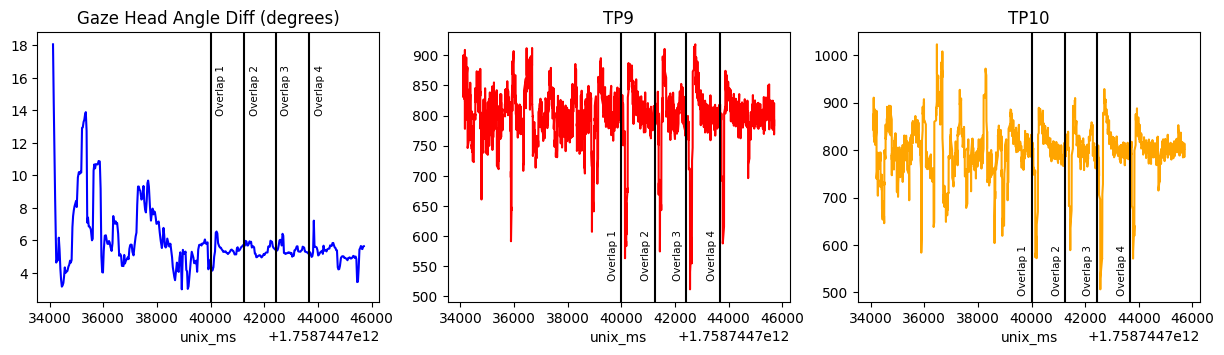

In [6]:
# Define the fig and axes. We'll create a 1x3 graph for this one.
fig, axes = plt.subplots(1,3, figsize=(15,3.5))

# First, render the `gaze_head_angle_diff` feature in the first column
_eye.plot(x='unix_ms', y='gaze_head_angle_diff', c='blue', ax=axes[0])
axes[0].set_title('Gaze Head Angle Diff (degrees)')
axes[0].legend().remove()

# Second, render TP9 in the second column
_eeg_raw.plot(x='unix_ms', y='TP9', c='red', ax=axes[1])
axes[1].set_title('TP9')
axes[1].legend().remove()

# Third, render TP10 in the third column
_eeg_raw.plot(x='unix_ms', y='TP10', c='orange', ax=axes[2])
axes[2].set_title('TP10')
axes[2].legend().remove()

# Fourth, render the calibration timestamps
for index, row in _cdf.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='black')
    axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-2, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[1].axvline(x=row['unix_ms'], c='black')
    axes[1].text(row['unix_ms']-500, axes[1].get_ylim()[0]+120, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[2].axvline(x=row['unix_ms'], c='black')
    axes[2].text(row['unix_ms']-500, axes[2].get_ylim()[0]+120, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

plt.show()

There are some immediate standout things we should recognize:

1. There's **ALWAYS** a 5-sec beginning that doesn't actually mean anything. We can cull that out.
2. The EEG data is, naturally, going to have a higher sample rate (its' 255Hz vs an optimal 90Hz)
3. The data is completely noisy all around.

Let's smooth out the data and see if we get improved results. To achieve the smoothing, I'm using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [ ]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider

x = _eye['unix_ms'].to_list()
y = _eye['gaze_head_angle_diff'].to_list()

def update_plot(window_length=10, polyorder=3):
    y_smoothed = savgol_filter(y, window_length=window_length, polyorder=polyorder, mode='nearest')

    plt.figure(figsize=(5,3.5))
    plt.plot(x, y, c='blue', alpha=0.5, label='raw')
    plt.plot(x, y_smoothed, c='green', label='smoothed')

    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=10, min=5, max=50, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=10.0, description='Window Length', max=50.0, min=5.0), IntSlider(value…

<function __main__.update_plot(window_length=10, polyorder=3)>

The visualization above indicates that a window of `22` and a poly order of `3` is optimal for smoothing out the signal while also not removing too many features. What about the EEG data (specifically the `TP9` channel)?

In [11]:
x = _eeg_raw['unix_ms'].to_list()
y = _eeg_raw['TP9'].to_list()

def update_plot(window_length=22, polyorder=3):
    y_smoothed = savgol_filter(y, window_length=window_length, polyorder=polyorder, mode='nearest')

    plt.figure(figsize=(5,3.5))
    plt.plot(x, y, c='blue', alpha=0.25, label='raw')
    plt.plot(x, y_smoothed, c='green', label='smoothed')

    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=100, min=50, max=200, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=100.0, description='Window Length', max=200.0, min=50.0), IntSlider(va…

<function __main__.update_plot(window_length=22, polyorder=3)>

This one is a bit harder to pinpoint the optimal parameters, because the data is inherently noisy. The same polyorder of `3` is common, but the window size appears to be somewhere between 100 and 200. We want to choose a dinow that won't let us lose TOO much about the signal features of the EEG data. For now, a window size of `125` might strike a fair balance.

Now, let's produce the same 3-column graph, but this time with the smoothed data.

In [17]:
# Define a helper function to plot stuff
def plot_line(_x, _y, _ax, _title=None, _color='black', _marker='x', _alpha=1.0, _label=None):
    _ax.plot(_x, _y, c=_color, marker=_marker, alpha=_alpha, label=_label)
    if _title is not None: _ax.set_title(_title)

# Let's get our X's and Y's first
eye_x = _eye['unix_ms'].to_list()
eye_y = _eye['gaze_head_angle_diff'].to_list()
eeg_x = _eeg_raw['unix_ms'].to_list()
eeg_y1 = _eeg_raw['TP9'].to_list()
eeg_y2 = _eeg_raw['TP10'].to_list()

# Create an update function to render our plots
def update_plot(wl1=22, po1=3, wl2=125, po2=3):
    # Calculate our smoothed versions
    eye_y_smoothed = savgol_filter(eye_y, window_length=wl1, polyorder=po1, mode='nearest')
    eeg_y1_smoothed = savgol_filter(eeg_y1, window_length=wl2, polyorder=po2, mode='nearest')
    eeg_y2_smoothed = savgol_filter(eeg_y2, window_length=wl2, polyorder=po2, mode='nearest')

    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(1,3, figsize=(15,3.5))

    # Plot eye data
    plot_line(eye_x, eye_y, axes[0], _color='blue', _marker=None, _alpha=0.25)
    plot_line(eye_x, eye_y_smoothed,  axes[0], _color='blue', _title='Gaze Head Angle Diff (degrees)', _marker=None)

    # Plot EEG data
    plot_line(eeg_x, eeg_y1, axes[1], _color='red', _title='TP9', _marker=None, _alpha=0.25)
    plot_line(eeg_x, eeg_y1_smoothed, axes[1], _color='red', _title='TP9', _marker=None)
    plot_line(eeg_x, eeg_y2, axes[2], _color='orange', _marker=None, _alpha=0.25)
    plot_line(eeg_x, eeg_y2_smoothed, axes[2], _color='orange', _title='TP10', _marker=None)

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0].axvline(x=row['unix_ms'], c='black')
        axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-2, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1].axvline(x=row['unix_ms'], c='black')
        axes[1].text(row['unix_ms']-500, axes[1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[2].axvline(x=row['unix_ms'], c='black')
        axes[2].text(row['unix_ms']-500, axes[2].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    plt.show()

interact(
    update_plot,
    wl1 = FloatSlider(value=22, min=5, max=50, step=1, description='Window Length (Eye)'),
    po1 = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order (Eye)'),
    wl2 = FloatSlider(value=125, min=50, max=200, step=1, description='Window Length (EEG)'),
    po2 = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order (EEG)')
)

interactive(children=(FloatSlider(value=22.0, description='Window Length (Eye)', max=50.0, min=5.0, step=1.0),…

<function __main__.update_plot(wl1=22, po1=3, wl2=125, po2=3)>

These visualizations point a better picture of what's going on. Namely:

1. It'll be somewhat hard to determine when the user blinks, based purely on the angle difference between the head and the eyes.
2. The overlaps occur BEFORE there is a massive fluctuation in the EEG data. This implies that the massive fluctuation is representative of the actual blink, and that there's apparently a delay here.

This bets the question: is there a better way to identify blinks from eye data? Let's try looking at two other features: `gaze_target_screen_pos_x` and `gaze_target_screen_pos_y`. Assuming we need a [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), let's try testing it out.

In [20]:
# Extract the x and y's of our eye data
x = _eye['unix_ms'].to_list()
y1 = _eye['gaze_target_screen_pos_x'].to_list()
y2 = _eye['gaze_target_screen_pos_y'].to_list()

def update_plot(window_length=22, polyorder=3):
    y1_smoothed = savgol_filter(y1, window_length=window_length, polyorder=polyorder, mode='nearest')
    y2_smoothed = savgol_filter(y2, window_length=window_length, polyorder=polyorder, mode='nearest')

    # Render as two subplots instead
    fig, axes = plt.subplots(2, 1, figsize=(7.5,5))

    # Plot
    axes[0].plot(x, y1, alpha=0.25)
    axes[0].plot(x, y1_smoothed)
    axes[1].plot(x, y2, alpha=0.25)
    axes[1].plot(x, y2_smoothed)

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0].axvline(x=row['unix_ms'], c='black')
        axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1].axvline(x=row['unix_ms'], c='black')
        axes[1].text(row['unix_ms']+200, axes[1].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=10, min=10, max=100, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=4, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=10.0, description='Window Length', min=10.0), IntSlider(value=4, descr…

<function __main__.update_plot(window_length=22, polyorder=3)>

This is, again a difficult proposition. There are only SOME areas where can noticeably see a change in the data. Namely:

- Right after "Overlap 1" in the X screen position.
- Right after "Overlap 3" in the X screen position.
- Right after "Overlap 4" in the Y screen position.
- A _slight_ suggestion of an "OVerlap 3" change in the Y screen position.

But these are only very slight suggestions. Let's look at each trial of P1 and observe this behavior.

### Trial 1

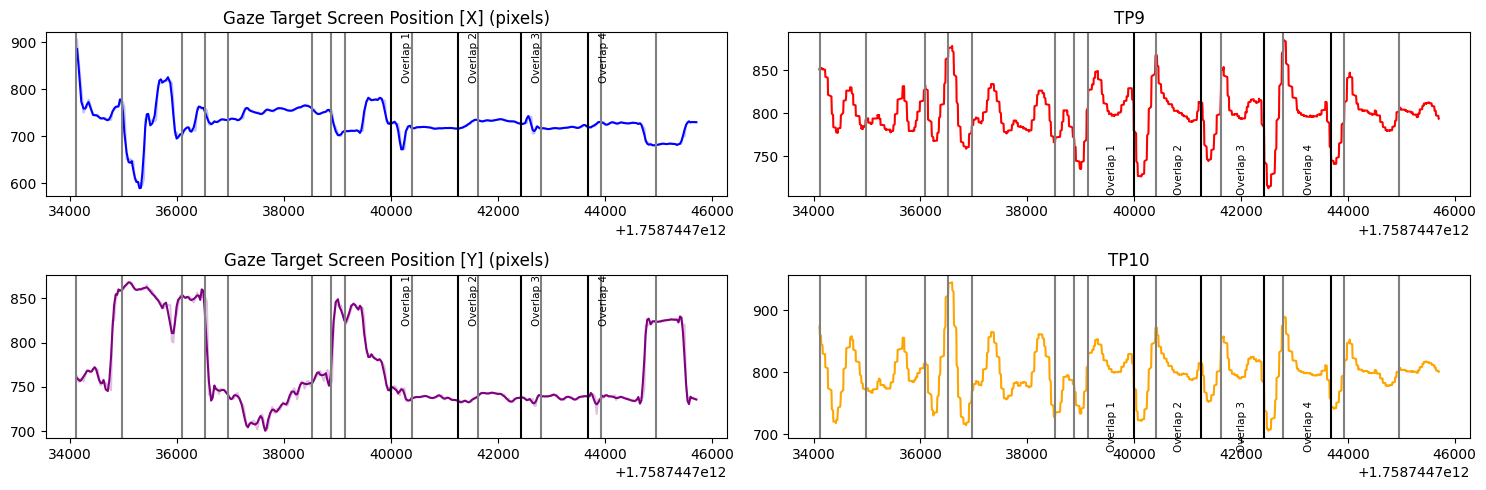

### Trial 2

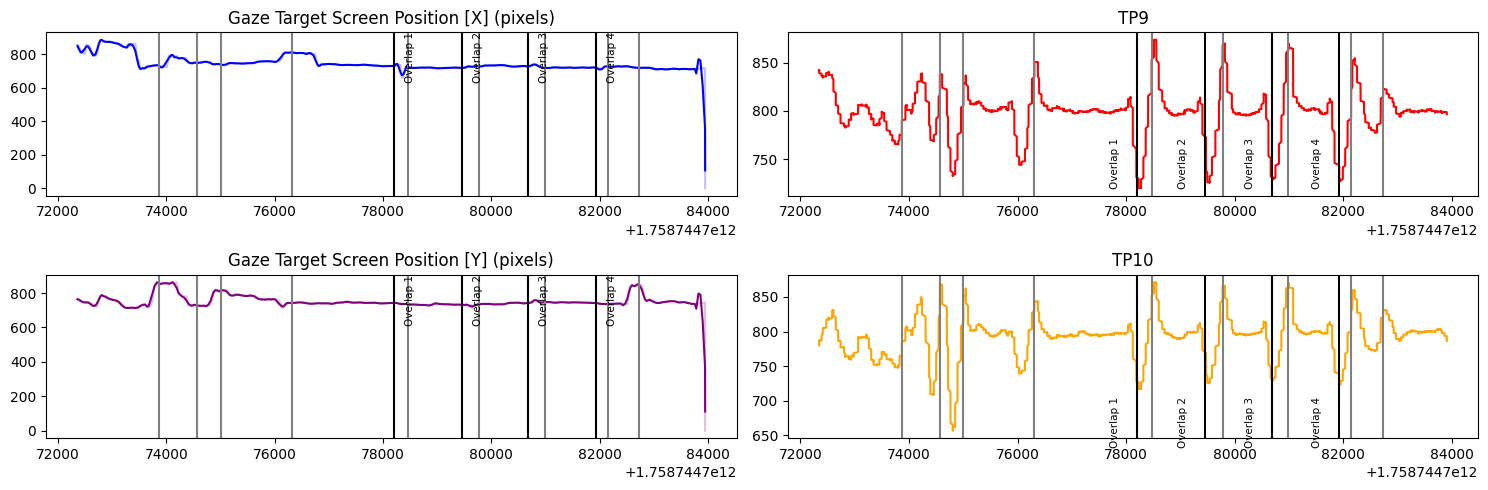

### Trial 3

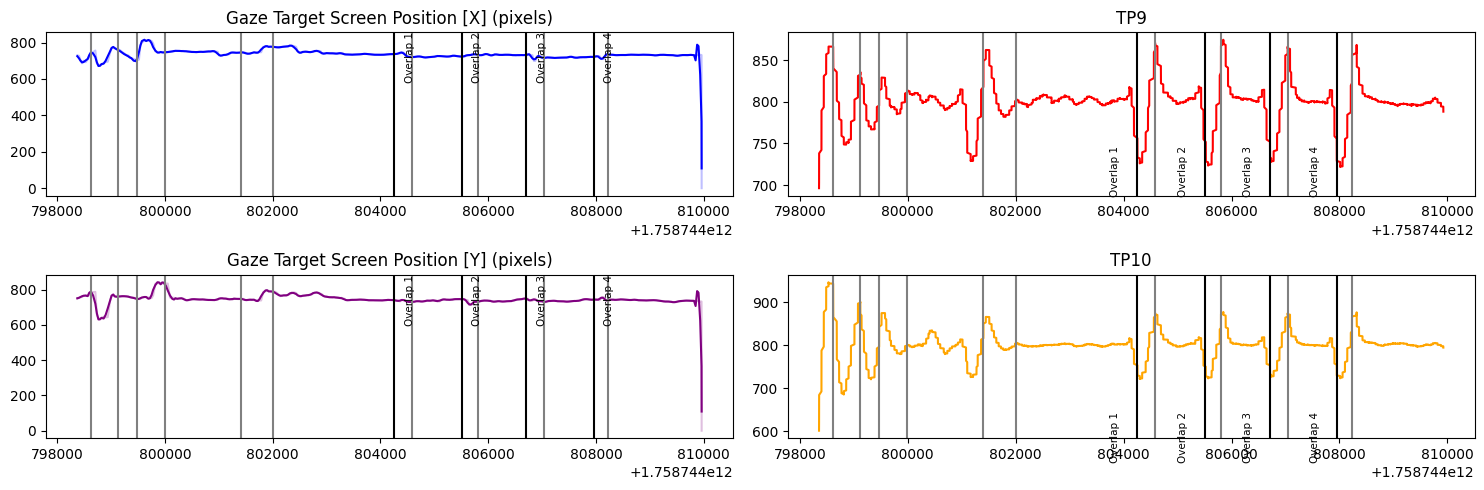

### Trial 4

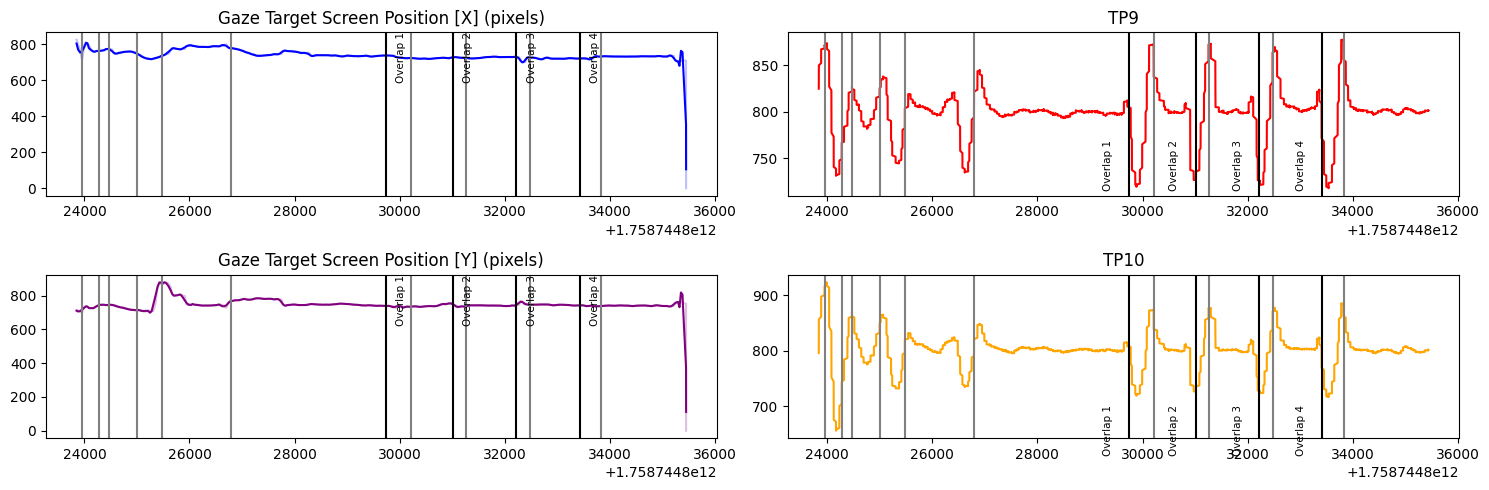

### Trial 5

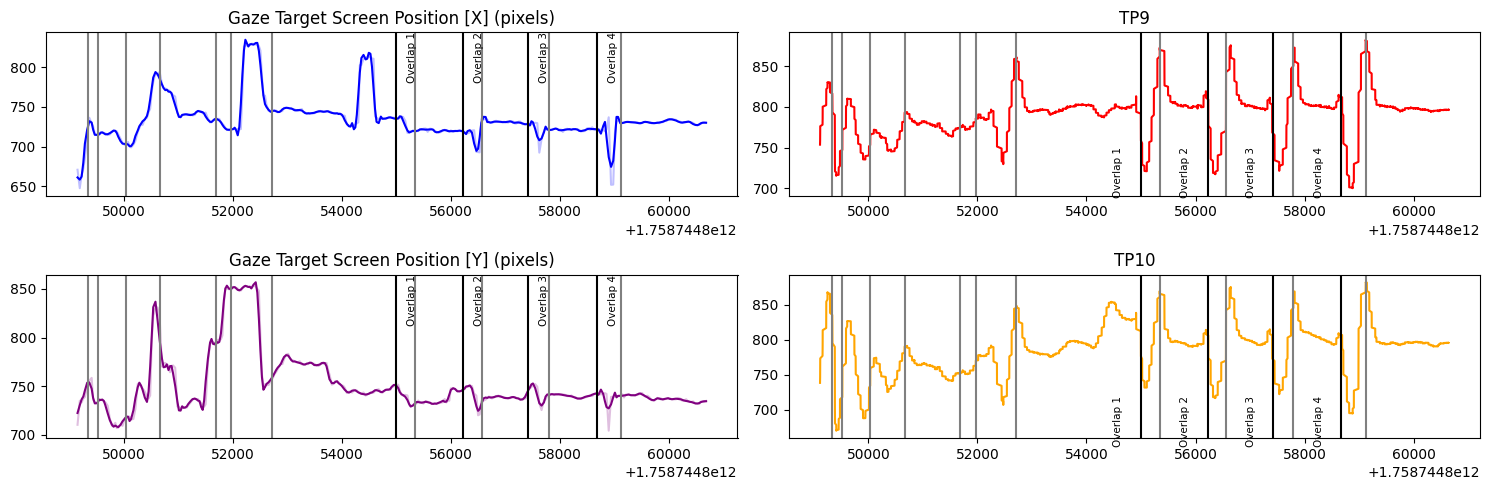

### Trial 6

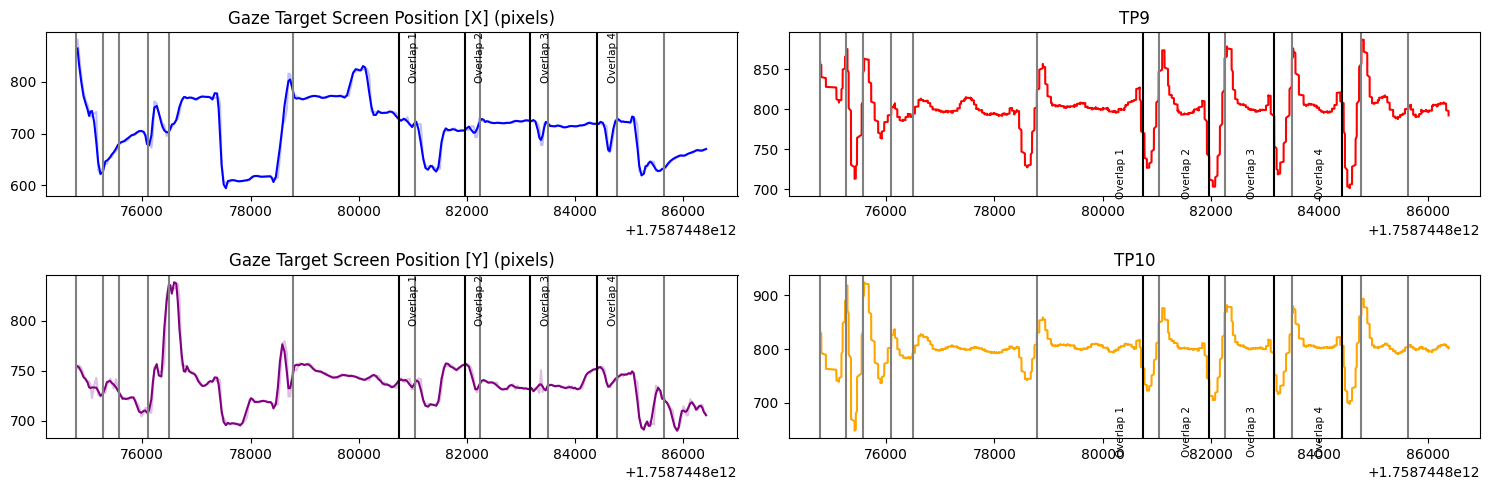

In [23]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data_separated/P1/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data_separated/P1/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=4, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=4, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()

This gives us some crucial information about P1 in particular:

1. **Trials 5** appears to give a very good metric to identify blinks. It's the only one that's consistent, as the other trials have noisy data.
2. Optimal blink detection might involve 2nd-order or even 3rd-order analysis.

## Another Example: P4_Muse2

Let's look at another participant: P4_Muse2

In [24]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data/P4_Muse2/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data/P4_Muse2/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=4, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=4, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './data/P4_Muse2/trials/calibrations.csv'

## Another-Another Example: P5

### Trial 1

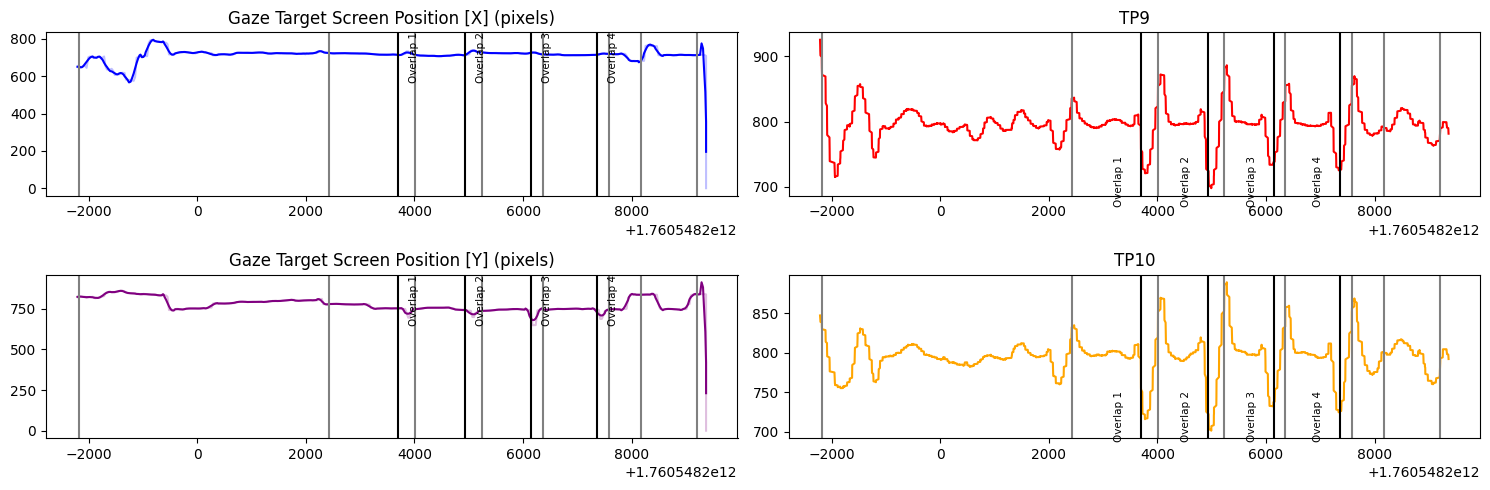

### Trial 2

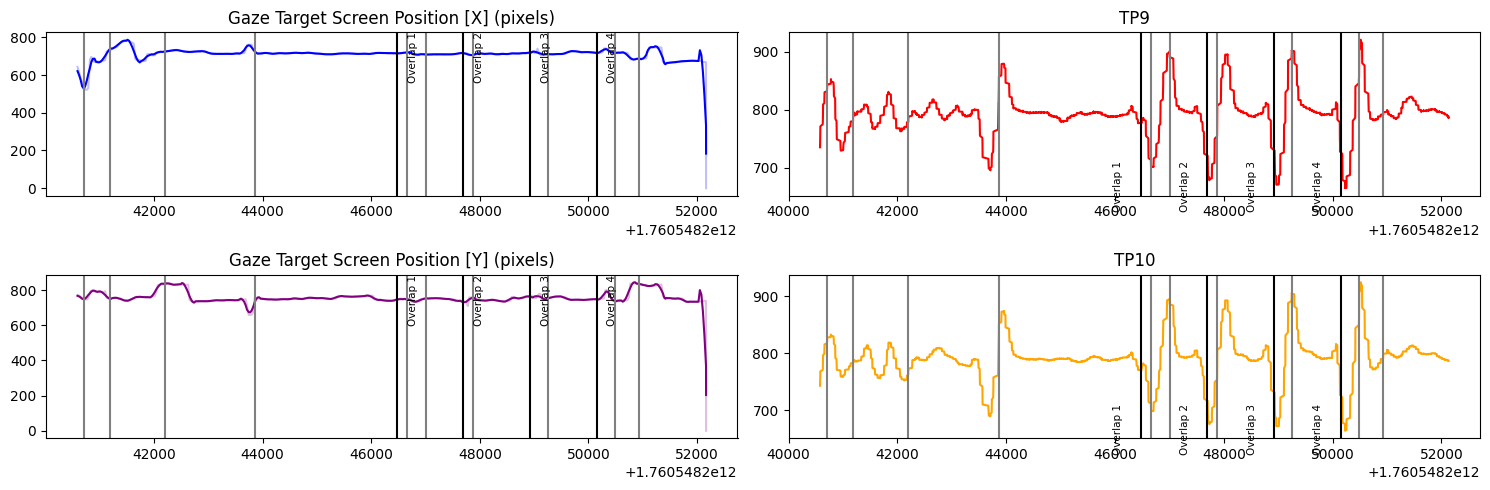

### Trial 3

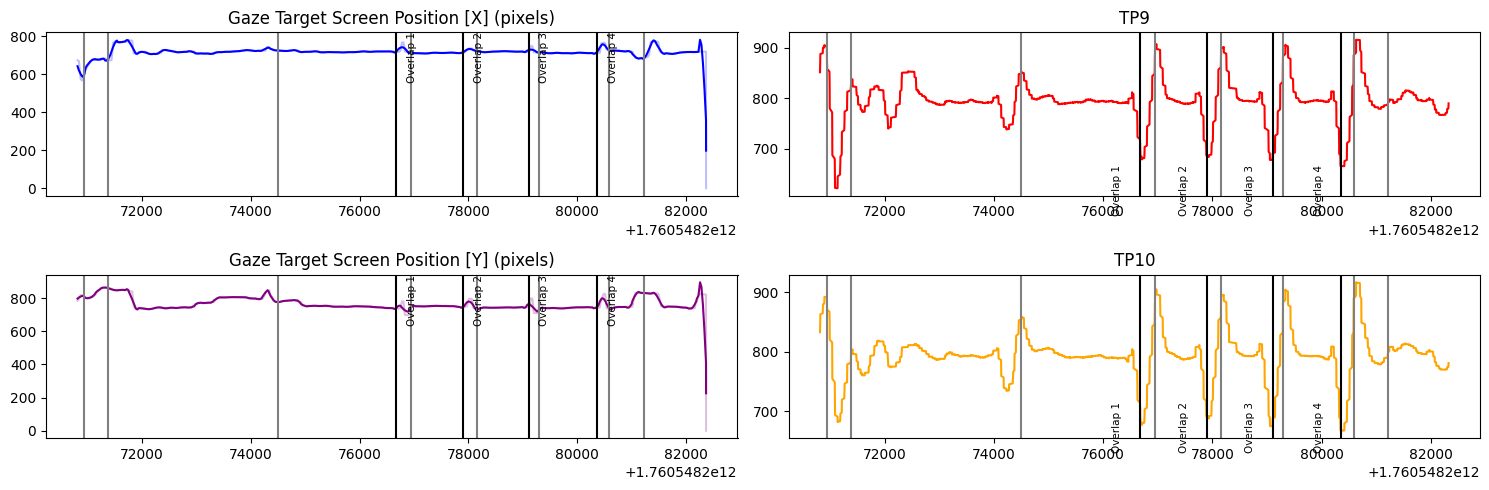

### Trial 4

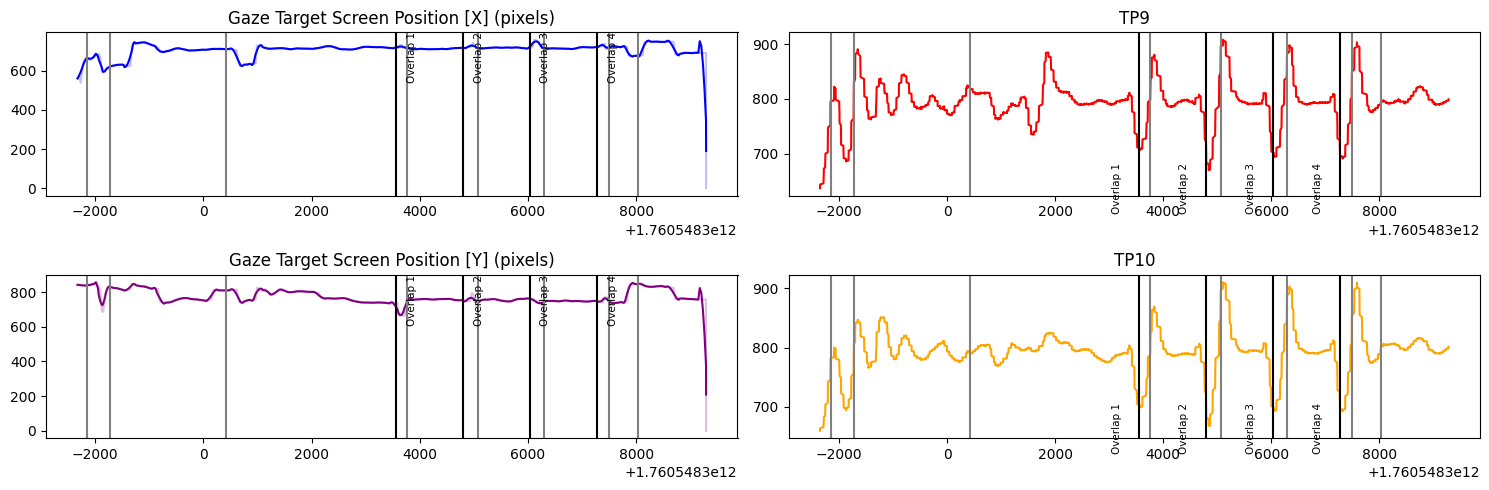

### Trial 5

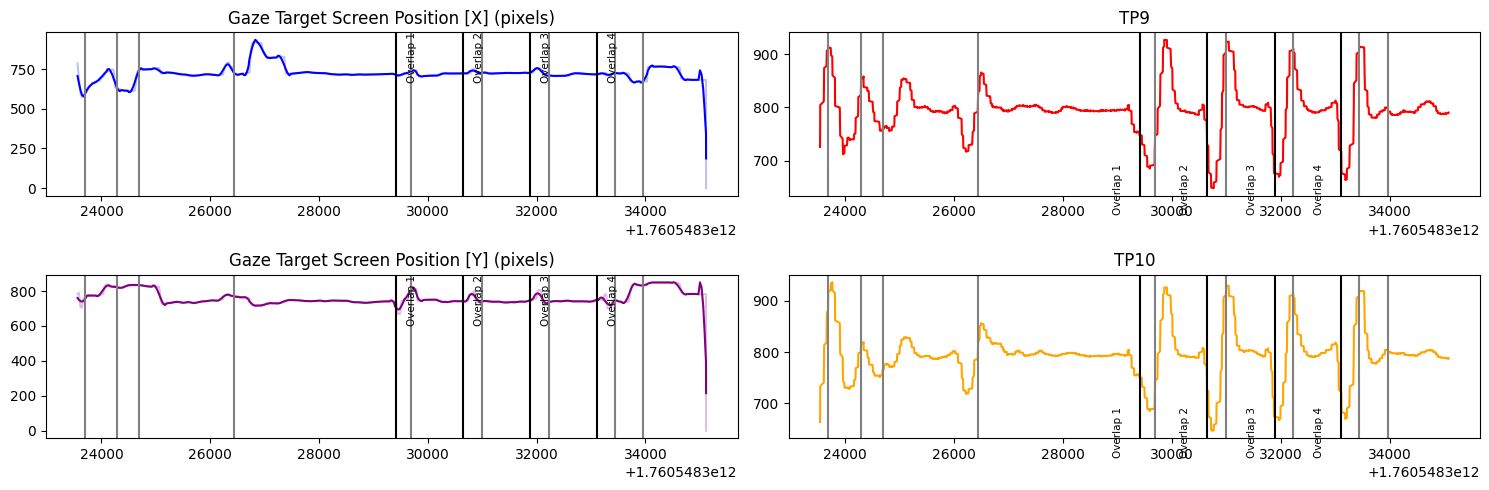

### Trial 6

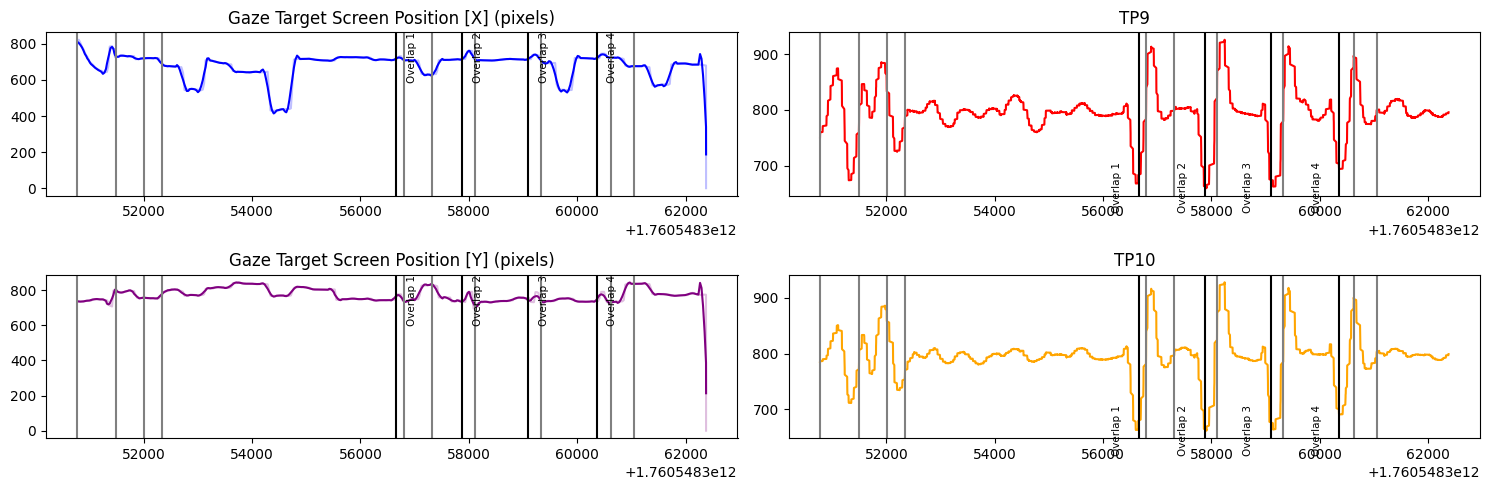

In [26]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data_separated/P5/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data_separated/P5/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=3, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=3, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()